<div style="border:3px solid #1f6fb2;border-radius:10px;padding:52px 44px;text-align:center;background:linear-gradient(160deg,#f8fbff 0%,#e4f0fc 100%);margin-bottom:8px;">
  <div style="font-size:56px;font-weight:900;color:#1f6fb2;letter-spacing:4px;margin-bottom:18px;font-family:sans-serif;">ICU SEPSIS RL</div>
  <div style="font-size:20px;font-weight:700;color:#1a3a5c;margin-bottom:8px;">Clinical Treatment Optimisation: Sepsis ICU Management</div>
  <div style="font-size:15px;font-style:italic;color:#4a6a8a;margin-bottom:38px;">Configuration A – Tabular Reinforcement Learning</div>
  <hr style="border:none;border-top:2px solid #1f6fb2;width:48%;margin:0 auto 28px auto;">
  <div style="font-size:14px;font-weight:600;color:#1a3a5c;margin-bottom:6px;">Student 1 &nbsp;|&nbsp; Student 2 &nbsp;|&nbsp; Student 3 &nbsp;|&nbsp; Student 4 &nbsp;|&nbsp; Student 5</div>
  <div style="font-size:13px;font-style:italic;color:#6a8aaa;">NOVA IMS – Master in Data Science &amp; Advanced Analytics – Reinforcement Learning – May 2026</div>
</div>

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up and Import Libraries](#2)
- [3. Environment Exploration](#3)
  - [3.1 State Space](#3_1)
  - [3.2 Transition Dynamics](#3_2)
  - [3.3 Reward Structure](#3_3)
  - [3.4 Random Baseline](#3_4)
  - [3.5 Feature-Outcome Relationship](#3_5)
  - [3.6 Action Space](#3_6)
- [4. Policy Iteration](#4)
  - [4.1 Rationale](#4_1)
  - [4.2 Implementation and Convergence](#4_2)
  - [4.3 Evaluation](#4_3)
- [5. Dyna-Q with Prioritized Sweeping and Shaping](#5)
  - [5.1 Rationale and Architecture](#5_1)
  - [5.2 Algorithm Implementation](#5_2)
  - [5.3 Optuna Hyperparameter Optimisation](#5_3)
  - [5.4 Final Training and Evaluation](#5_4)
- [6. Candidate Algorithms](#6)
  - [6.1 Expected SARSA with Eligibility Traces and Shaping](#6_1)
  - [6.2 Q-Learning with Learning Rate Decay and Shaping](#6_2)
  - [6.3 SARSA with Eligibility Traces and Shaping](#6_3)
  - [6.4 Double Q-Learning and Shaping](#6_4)
  - [6.5 Monte Carlo Control and Shaping](#6_5)
  - [6.6 V-PI Warm-Start and Shaping](#6_6)
  - [6.7 Comparative Analysis and Algorithm Selection](#6_7)
- [7. Results and Visualizations](#7)
- [8. Comparative Analysis](#8)


# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

Configuration A applies **tabular reinforcement learning** to the ICU-Sepsis-v2 environment,
a discrete MDP derived from real MIMIC-III patient data. The state space consists of 716
discrete states (714 clinical plus 2 terminal: survived and died), and the action space
contains 25 treatment combinations (5 vasopressor levels x 5 IV fluid dose levels).

**Fixed configuration:** sofa_bias = 5.0, lam = 0.02 (as defined in env_setup.py).

**Implementation pattern (applied to every algorithm):**

1. Define a reusable training function `train_ALGO(hyperparameters, n_episodes, verbose)`
2. Optuna calls this function 50 times with different hyperparameter combinations (50k episodes each)
3. The best combination is used for the final training run (full episodes, verbose output)

**Primary evaluation metrics:**
- **Survival Rate:** policy evaluation over 1000 episodes after training
- **Learning Curve:** rolling 500-episode survival rate during training, showing the speed
  at which each algorithm learns to improve patient outcomes over time


# <font color='#2f94d7' size=6>**2. Set Up and Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [6]:
!pip install icu-sepsis stable-baselines3 torch gymnasium optuna

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time, heapq
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'
SEED = 42
np.random.seed(SEED)

from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM, make_sepsis_env,
)
from envs.continuous_sepsis_env import ContinuousICUSepsisEnv, FEATURE_NAMES

print(f'ICU-Sepsis-v2  |  States: {N_STATES}  |  Actions: {N_ACTIONS}')
print(f'Fixed config   |  sofa_bias={SOFA_BIAS}, lam={LAM}')
print(f'Optuna version : {optuna.__version__}')

ICU-Sepsis-v2  |  States: 716  |  Actions: 25
Fixed config   |  sofa_bias=5.0, lam=0.02
Optuna version : 4.8.0


In [10]:
import functions_ConfigA as fa

# Expose all symbols into notebook namespace
from functions_ConfigA import (
    H_COL, B0, B1, B2, B3, B4, B5, B6, REF_RAND, REF_PI,
    C_PI, C_DQ, C_ES, C_QL, C_SAR, C_DQL, C_MC, C_WS,
    smooth, silent_eval, evaluate_policy, make_env,
    make_optuna_callback, plot_results, plot_pi_results,
    train_dynaq_ps, train_expected_sarsa, train_qlearning,
    train_sarsa, train_double_ql, train_mc, train_warmstart,
)

import os; os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'
S = N_STATES; A = N_ACTIONS
N_TRIALS   = 30
TRIAL_EPS  = 40_000
TRIAL_EVAL = 300
SEED       = fa.SEED

print(f'functions_ConfigA loaded: {len([x for x in dir(fa) if not x.startswith("_")])} symbols')
print(f'Config: sofa_bias={SOFA_BIAS}, lam={LAM}')
print(f'Optuna: {N_TRIALS} trials x {TRIAL_EPS:,} episodes x {TRIAL_EVAL} eval')


functions_ConfigA loaded: 42 symbols
Config: sofa_bias=5.0, lam=0.02
Optuna: 30 trials x 40,000 episodes x 300 eval


# <font color='#2f94d7' size=6>**3. Environment Exploration**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [13]:
env = fa.make_env()
raw = env.unwrapped
P_mat = raw._tx_mat.copy()
R_mat = (raw._r_mat * raw._tx_mat).sum(axis=2)
sofa_scores = raw._sofa_scores.flatten()
d0   = raw._d_0.copy()
cont_env = ContinuousICUSepsisEnv(params=env)
cluster_centers = cont_env._cluster_centers.copy()
env.close(); cont_env.close()
print(f'P_mat: {P_mat.shape}  |  R_mat: {R_mat.shape}  |  Clusters: {cluster_centers.shape}')
print(f'SOFA range: [{sofa_scores[:S-2].min():.1f}, {sofa_scores[:S-2].max():.1f}]')


P_mat: (716, 25, 716)  |  R_mat: (716, 25)  |  Clusters: (716, 47)
SOFA range: [0.0, 18.0]


## <font color='#2f94d7' size=6>**3.1 State Space**</font> <a class="anchor" id="3_1"></a>

[Back to TOC](#toc)

714 clinical states derived from MIMIC-III patient clustering, plus 2 terminal absorbing
states (STATE_DIED=713, STATE_SURVIVED=714). Each state corresponds to a cluster of patients
with similar physiological profiles. The SOFA score (Sequential Organ Failure Assessment)
characterises clinical severity per state. With sofa_bias=5.0, the initial distribution
is weighted toward sicker patients (higher SOFA scores).


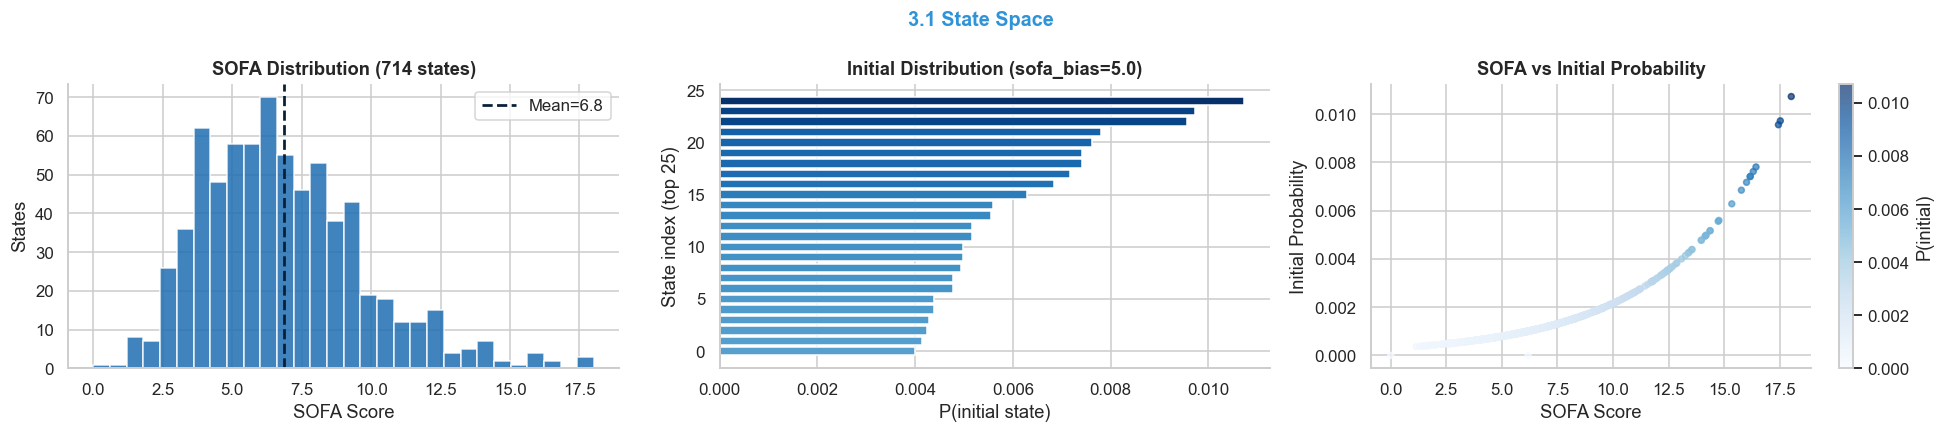

Active initial states: 712 / 714
Weighted mean SOFA   : 9.02


In [15]:
fig,axes=plt.subplots(1,3,figsize=(18,4))
fig.suptitle('3.1 State Space',fontsize=13,fontweight='bold',color=H_COL)
sofa_cl=sofa_scores[:S-2]; d0_cl=d0[:S-2]
axes[0].hist(sofa_cl,bins=30,color=B2,edgecolor='white',alpha=0.85)
axes[0].axvline(np.mean(sofa_cl),color=B0,ls='--',lw=1.8,label=f'Mean={np.mean(sofa_cl):.1f}')
axes[0].set_xlabel('SOFA Score'); axes[0].set_ylabel('States')
axes[0].set_title('SOFA Distribution (714 states)',fontweight='bold')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
top_idx=np.argsort(d0_cl)[-25:]
axes[1].barh(range(25),d0_cl[top_idx],
             color=[plt.cm.Blues(0.3+0.7*v/d0_cl[top_idx].max()) for v in d0_cl[top_idx]],
             edgecolor='white')
axes[1].set_xlabel('P(initial state)'); axes[1].set_ylabel('State index (top 25)')
axes[1].set_title(f'Initial Distribution (sofa_bias={SOFA_BIAS})',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
sc=axes[2].scatter(sofa_cl,d0_cl,c=d0_cl,cmap='Blues',s=15,alpha=0.7)
plt.colorbar(sc,ax=axes[2],label='P(initial)')
axes[2].set_xlabel('SOFA Score'); axes[2].set_ylabel('Initial Probability')
axes[2].set_title('SOFA vs Initial Probability',fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_1.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Active initial states: {np.sum(d0_cl>0)} / {S-2}')
print(f'Weighted mean SOFA   : {np.average(sofa_cl,weights=d0_cl):.2f}')


## <font color='#2f94d7' size=6>**3.2 Transition Dynamics**</font> <a class="anchor" id="3_2"></a>

[Back to TOC](#toc)

P(s'|s,a) has shape (716,25,716). Derived from real trajectories, most transitions are
stochastic. The branching factor (reachable next states per action) and the probability of
reaching terminal states are key characteristics that determine algorithm difficulty.


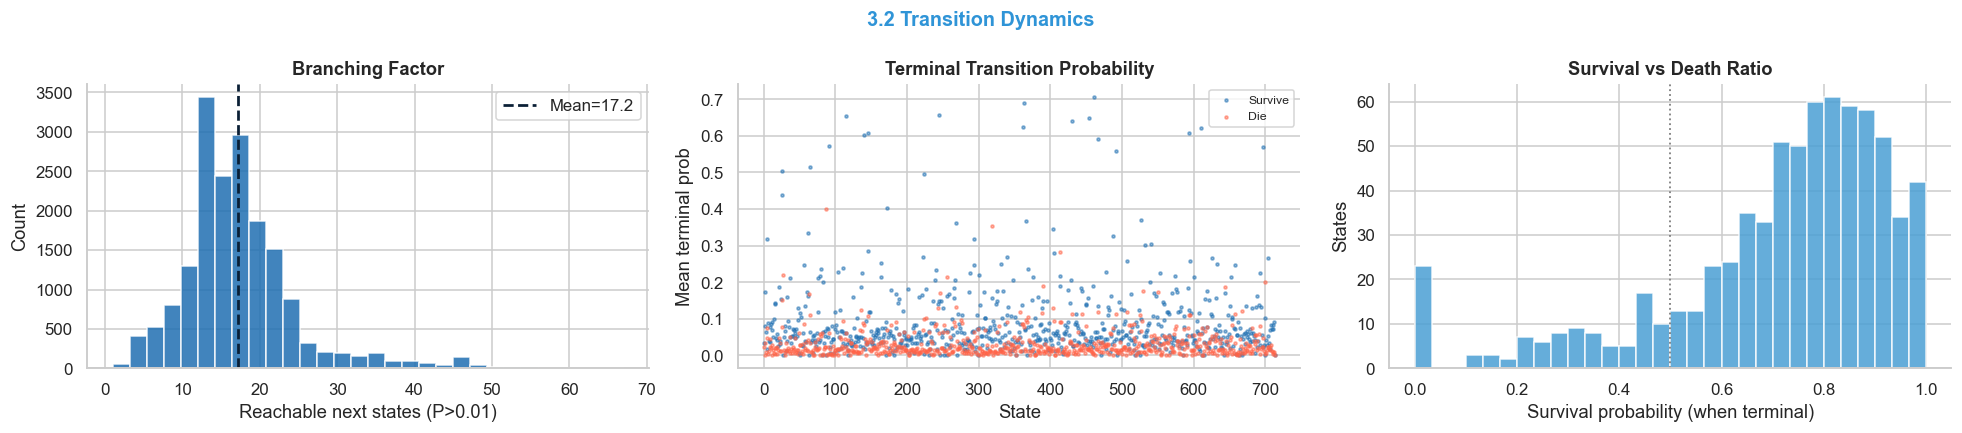

Sparsity: 88.0%  |  Mean branching: 17.2


In [17]:
fig,axes=plt.subplots(1,3,figsize=(18,4))
fig.suptitle('3.2 Transition Dynamics',fontsize=13,fontweight='bold',color=H_COL)
P_cl=P_mat[:S-2]; branching=(P_cl>0.01).sum(axis=2)
axes[0].hist(branching.flatten(),bins=30,color=B2,edgecolor='white',alpha=0.85)
axes[0].axvline(np.mean(branching),color=B0,ls='--',lw=1.8,label=f'Mean={np.mean(branching):.1f}')
axes[0].set_xlabel('Reachable next states (P>0.01)'); axes[0].set_ylabel('Count')
axes[0].set_title('Branching Factor',fontweight='bold')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
p_surv=P_cl[:,:,STATE_SURVIVED].mean(axis=1); p_die=P_cl[:,:,STATE_DIED].mean(axis=1)
axes[1].scatter(range(S-2),p_surv,s=4,color=B2,alpha=0.5,label='Survive')
axes[1].scatter(range(S-2),p_die,s=4,color='tomato',alpha=0.5,label='Die')
axes[1].set_xlabel('State'); axes[1].set_ylabel('Mean terminal prob')
axes[1].set_title('Terminal Transition Probability',fontweight='bold')
axes[1].legend(fontsize=8); axes[1].spines[['top','right']].set_visible(False)
surv_ratio=np.where((p_surv+p_die)>0,p_surv/(p_surv+p_die+1e-9),0.5)
axes[2].hist(surv_ratio,bins=30,color=B3,edgecolor='white',alpha=0.85)
axes[2].axvline(0.5,color='grey',ls=':',lw=1.2)
axes[2].set_xlabel('Survival probability (when terminal)'); axes[2].set_ylabel('States')
axes[2].set_title('Survival vs Death Ratio',fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_2.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Sparsity: {(1-(P_cl>0).mean())*100:.1f}%  |  Mean branching: {np.mean(branching):.1f}')


## <font color='#2f94d7' size=6>**3.3 Reward Structure**</font> <a class="anchor" id="3_3"></a>

[Back to TOC](#toc)

The reward is terminal-only and sparse: +1.0 at survival, 0.0 at death, 0.0 at all
intermediate steps. With lam=0.02, a treatment intensity penalty is subtracted at each
step. This extreme sparsity is the primary challenge for model-free credit assignment.


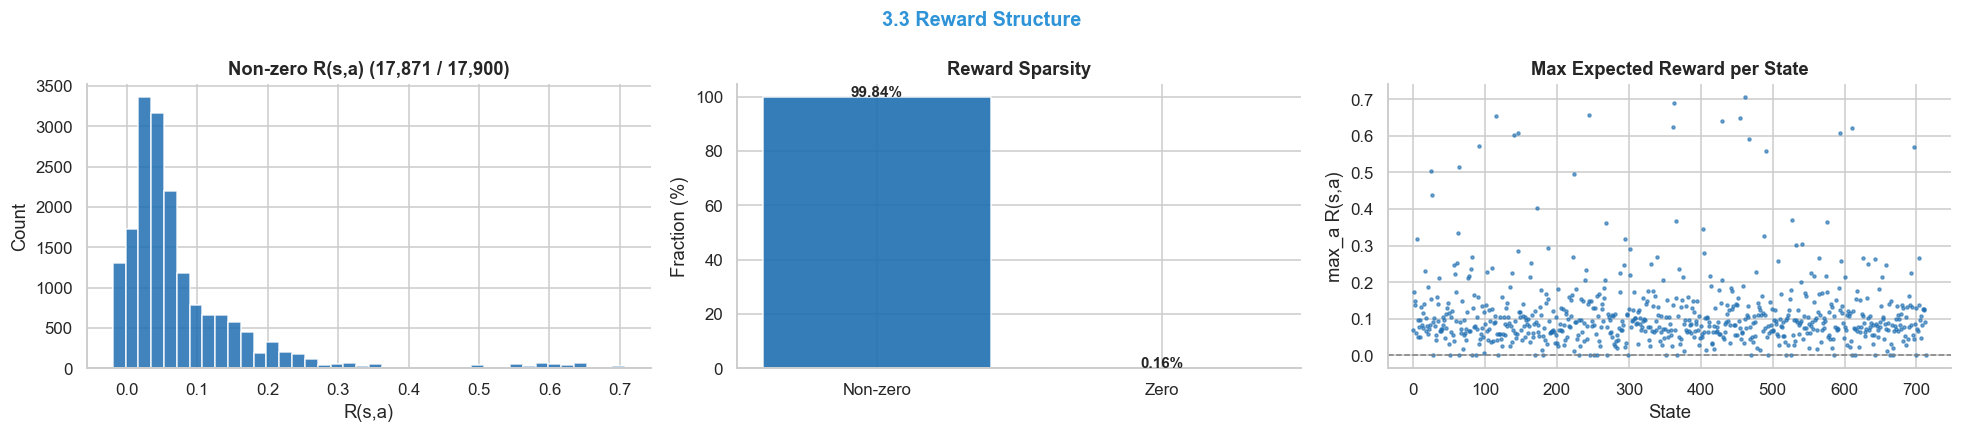

Non-zero R: 99.838%  |  R range: [-0.0200, 0.7076]


In [19]:
fig,axes=plt.subplots(1,3,figsize=(18,4))
fig.suptitle('3.3 Reward Structure',fontsize=13,fontweight='bold',color=H_COL)
nz=R_mat[R_mat!=0].flatten()
axes[0].hist(nz,bins=40,color=B2,edgecolor='white',alpha=0.85)
axes[0].set_xlabel('R(s,a)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Non-zero R(s,a) ({len(nz):,} / {R_mat.size:,})',fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
nzf=np.mean(R_mat!=0)*100
axes[1].bar(['Non-zero','Zero'],[nzf,100-nzf],color=[B2,B6],edgecolor='white',alpha=0.9)
axes[1].set_ylabel('Fraction (%)'); axes[1].set_title('Reward Sparsity',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
for i,v in enumerate([nzf,100-nzf]):
    axes[1].text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=10,fontweight='bold')
axes[2].scatter(range(S-2),R_mat[:S-2].max(axis=1),s=4,color=B2,alpha=0.6)
axes[2].axhline(0,color='grey',ls='--',lw=1.0)
axes[2].set_xlabel('State'); axes[2].set_ylabel('max_a R(s,a)')
axes[2].set_title('Max Expected Reward per State',fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_3.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Non-zero R: {nzf:.3f}%  |  R range: [{R_mat.min():.4f}, {R_mat.max():.4f}]')


## <font color='#2f94d7' size=6>**3.4 Random Baseline**</font> <a class="anchor" id="3_4"></a>

[Back to TOC](#toc)

1000 episodes with a uniformly random policy establish the lower bound for all learned
policies and the baseline for the survival rate and learning curve comparisons.


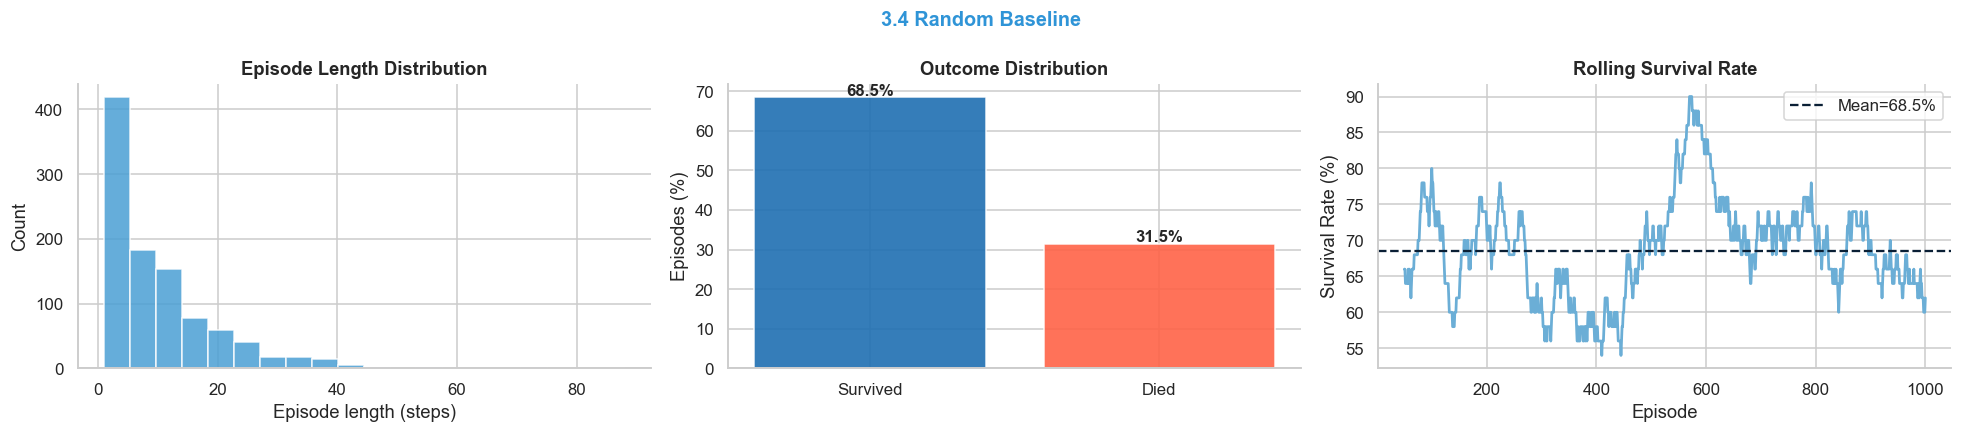

Random baseline: 68.5% +/- 2.9%  |  Mean length: 10.3 steps
Random baseline: 68.5% | mean return: 0.5818


In [21]:
np.random.seed(SEED); env_r=fa.make_env(); rand_returns,rand_lengths=[],[]
for ep in range(1000):
    obs,_=env_r.reset(seed=np.random.randint(100_000)); total_r,steps,done=0.0,0,False
    while not done:
        obs,r,te,tr,_=env_r.step(env_r.action_space.sample()); total_r+=r; steps+=1; done=te or tr
    rand_returns.append(total_r); rand_lengths.append(steps)
env_r.close()
rand_returns=np.array(rand_returns); rand_lengths=np.array(rand_lengths)
rand_survival=float(np.mean(rand_returns>0))*100
rand_surv_ci =1.96*np.sqrt((rand_survival/100)*(1-rand_survival/100)/1000)*100
fig,axes=plt.subplots(1,3,figsize=(18,4))
fig.suptitle('3.4 Random Baseline',fontsize=13,fontweight='bold',color=H_COL)
axes[0].hist(rand_lengths,bins=20,color=B3,edgecolor='white',alpha=0.85)
axes[0].set_xlabel('Episode length (steps)'); axes[0].set_ylabel('Count')
axes[0].set_title('Episode Length Distribution',fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[1].bar(['Survived','Died'],[rand_survival,100-rand_survival],
            color=[B2,'tomato'],edgecolor='white',alpha=0.9)
axes[1].set_ylabel('Episodes (%)'); axes[1].set_title('Outcome Distribution',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
for i,v in enumerate([rand_survival,100-rand_survival]):
    axes[1].text(i,v+0.5,f'{v:.1f}%',ha='center',fontsize=11,fontweight='bold')
roll=smooth((rand_returns>0).astype(float)*100,50)
axes[2].plot(np.arange(50,1001),roll,color=REF_RAND,lw=1.8)
axes[2].axhline(rand_survival,color=B0,ls='--',lw=1.5,label=f'Mean={rand_survival:.1f}%')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Survival Rate (%)')
axes[2].set_title('Rolling Survival Rate',fontweight='bold')
axes[2].legend(); axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_4.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Random baseline: {rand_survival:.1f}% +/- {rand_surv_ci:.1f}%  |  Mean length: {np.mean(rand_lengths):.1f} steps')

rand_mean_ret = float(np.mean(rand_returns))
print(f'Random baseline: {rand_survival:.1f}% | mean return: {rand_mean_ret:.4f}')

## <font color='#2f94d7' size=6>**3.5 Feature-Outcome Relationship**</font> <a class="anchor" id="3_5"></a>

[Back to TOC](#toc)

Each of the 714 clinical states corresponds to a cluster centre in the 47-dimensional
physiological feature space shared with Config B. The correlation of each feature with
V_PI(s) (the survival probability under optimal treatment) reveals which physiological
variables are most associated with patient outcomes, providing a clinical interpretation
of the state space that bridges both configurations.


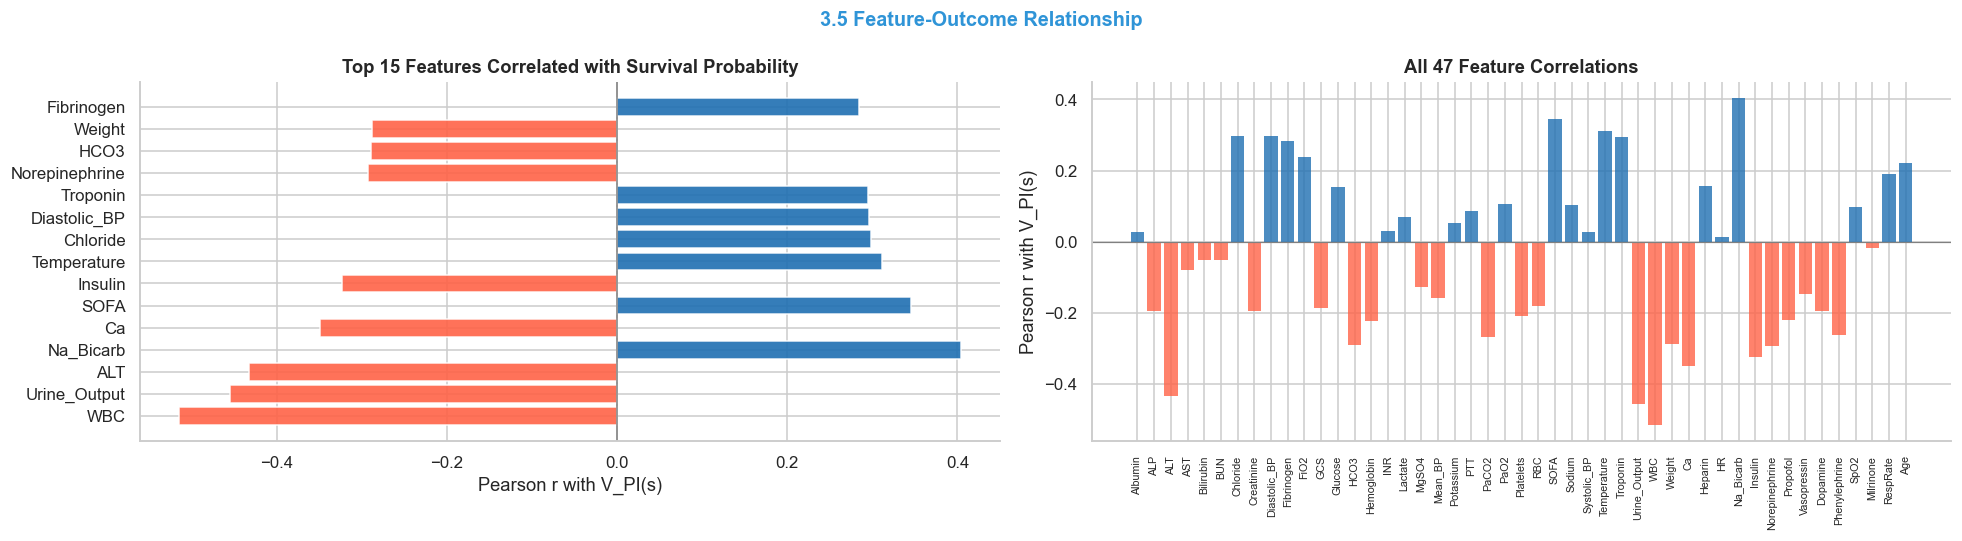

Top 5 positive: ['Na_Bicarb']
Top 5 negative: ['WBC', 'Urine_Output', 'ALT', 'Ca', 'Insulin']


In [23]:
env0=fa.make_env(); raw0=env0.unwrapped
P0=raw0._tx_mat.copy(); R0=(raw0._r_mat*raw0._tx_mat).sum(axis=2); env0.close()
pol0=np.zeros(S,dtype=int)
for _ in range(100):
    V0=np.zeros(S)
    for __ in range(5000):
        Vn=np.array([R0[s,pol0[s]]+GAMMA*P0[s,pol0[s]]@V0 for s in range(S)])
        if np.max(np.abs(Vn-V0))<1e-8: break
        V0=Vn
    new_pol0=np.argmax(R0+GAMMA*np.einsum('ijk,k->ij',P0,V0),axis=1)
    if np.array_equal(new_pol0,pol0): break
    pol0=new_pol0

V_preview=V0[:S-2]
feats=cluster_centers[:S-2]
corrs=np.array([np.corrcoef(feats[:,j],V_preview)[0,1] for j in range(47)])
sidx=np.argsort(np.abs(corrs))[::-1]
fig,axes=plt.subplots(1,2,figsize=(18,5))
fig.suptitle('3.5 Feature-Outcome Relationship',fontsize=13,fontweight='bold',color=H_COL)
top15=sidx[:15]
cols=[B2 if corrs[i]>=0 else 'tomato' for i in top15]
axes[0].barh([FEATURE_NAMES[i] for i in top15],corrs[top15],color=cols,edgecolor='white',alpha=0.9)
axes[0].axvline(0,color='grey',lw=1.0)
axes[0].set_xlabel('Pearson r with V_PI(s)')
axes[0].set_title('Top 15 Features Correlated with Survival Probability',fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
ca=[B2 if v>=0 else 'tomato' for v in corrs]
axes[1].bar(range(47),corrs,color=ca,edgecolor='none',alpha=0.8,width=0.8)
axes[1].set_xticks(range(47)); axes[1].set_xticklabels(FEATURE_NAMES,rotation=90,fontsize=7)
axes[1].axhline(0,color='grey',lw=0.8)
axes[1].set_ylabel('Pearson r with V_PI(s)'); axes[1].set_title('All 47 Feature Correlations',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_5.png',dpi=150,bbox_inches='tight'); plt.show()
print('Top 5 positive:', [FEATURE_NAMES[i] for i in sidx[:5] if corrs[i]>0])
print('Top 5 negative:', [FEATURE_NAMES[i] for i in sidx if corrs[i]<0][:5])

## <font color='#2f94d7' size=6>**3.6 Action Space**</font> <a class="anchor" id="3_6"></a>

[Back to TOC](#toc)

25 actions encode all combinations of 5 vasopressor x 5 IV fluid dose levels. Treatment
intensity = (vaso_level + fluid_level)/8, ranging from 0 (no treatment) to 1 (maximum).
The penalty lam=0.02 per step incentivises parsimonious treatment.


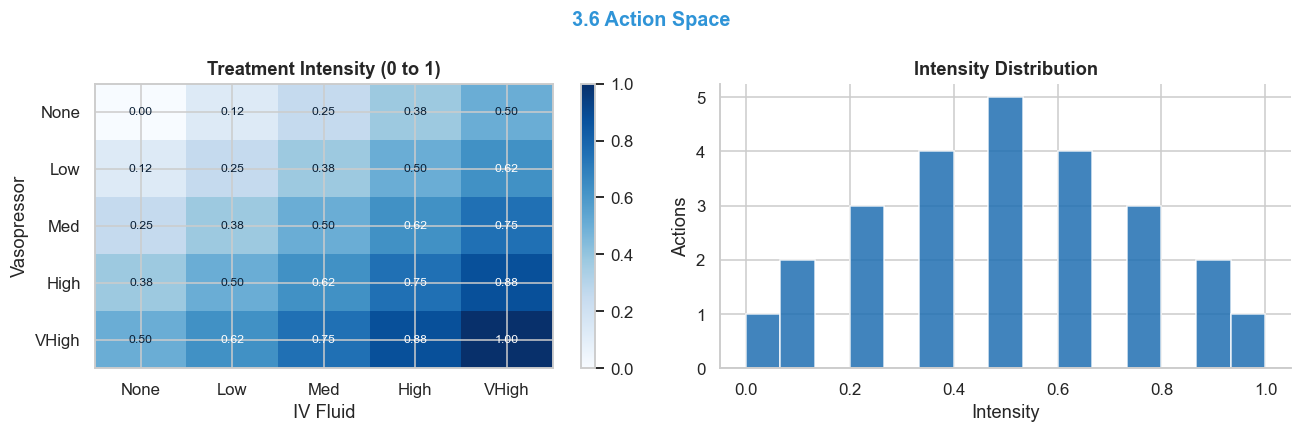

Actions: 25  |  Intensity range: [0.000, 1.000]
Max penalty per step: lam x max_intensity = 0.02 x 1.000 = 0.0200


In [25]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle('3.6 Action Space',fontsize=13,fontweight='bold',color=H_COL)
im=axes[0].imshow(INTENSITY.reshape(5,5),cmap='Blues',aspect='auto',vmin=0,vmax=1)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(['None','Low','Med','High','VHigh'])
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(['None','Low','Med','High','VHigh'])
axes[0].set_xlabel('IV Fluid'); axes[0].set_ylabel('Vasopressor')
axes[0].set_title('Treatment Intensity (0 to 1)',fontweight='bold')
plt.colorbar(im,ax=axes[0])
for i in range(5):
    for j in range(5):
        v=INTENSITY.reshape(5,5)[i,j]
        axes[0].text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=8,
                     color='white' if v>0.6 else B0)
axes[1].hist(INTENSITY,bins=15,color=B2,edgecolor='white',alpha=0.85)
axes[1].set_xlabel('Intensity'); axes[1].set_ylabel('Actions')
axes[1].set_title('Intensity Distribution',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_6.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Actions: {A}  |  Intensity range: [{INTENSITY.min():.3f}, {INTENSITY.max():.3f}]')
print(f'Max penalty per step: lam x max_intensity = {LAM:.2f} x {INTENSITY.max():.3f} = {LAM*INTENSITY.max():.4f}')

# <font color='#2f94d7' size=6>**4. Policy Iteration**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**4.1 Rationale**</font> <a class="anchor" id="4_1"></a>

[Back to TOC](#toc)

Policy Iteration is provably optimal when the full MDP model is available. It serves as
the gold standard upper bound and provides V_PI(s) - the survival probability from each
state under the optimal policy - which is used as the shaping potential for all model-free
algorithms. With gamma=1.0, V_PI(s) equals the probability of survival from state s,
making it directly interpretable as a clinical acuity score.

**Potential-based reward shaping (Ng et al., 1999):** all model-free algorithms receive
a shaped reward r'(s,a,s') = r + gamma*V_PI(s')*(not done) - V_PI(s), converting the
sparse terminal signal into a dense per-step reward proportional to change in survival
probability. This transformation is policy-invariant: the optimal policy under r' is
identical to the optimal policy under r.


In [28]:
env_pi=fa.make_env(); raw_pi=env_pi.unwrapped
P_pi  =raw_pi._tx_mat.copy()
R_sa  =(raw_pi._r_mat*raw_pi._tx_mat).sum(axis=2)
env_pi.close()

pi_policy=np.zeros(S,dtype=int); pi_hist_V=[np.zeros(S)]; pi_eval_iters=[]; t0_pi=time.time()
print('Running Policy Iteration...'); print('-'*48)
for it in range(1000):
    V=np.zeros(S)
    for _ in range(10000):
        Vn=np.array([R_sa[s,pi_policy[s]]+GAMMA*P_pi[s,pi_policy[s]]@V for s in range(S)])
        if np.max(np.abs(Vn-V))<1e-8: break
        V=Vn
    n_sw=_+1; pi_eval_iters.append(n_sw)
    new_pol=np.argmax(R_sa+GAMMA*np.einsum('ijk,k->ij',P_pi,V),axis=1)
    pi_hist_V.append(V.copy())
    chg=int((new_pol!=pi_policy).sum())
    print(f'  Iteration {it+1}: {n_sw:>4} sweeps | Changed: {chg:>4} | Mean V: {np.mean(V[:S-2]):.4f}')
    if np.array_equal(new_pol,pi_policy):
        print('-'*48); print(f'  Converged in {it+1} iteration(s)'); break
    pi_policy=new_pol
pi_V    =V.copy(); pi_time=time.time()-t0_pi

R_shaped=R_sa+GAMMA*np.einsum('ijk,k->ij',P_pi,pi_V)-pi_V[:,np.newaxis]
print(f'\nConverged | {pi_time:.3f}s | {sum(pi_eval_iters)} sweeps | Shaped R: [{R_shaped.min():.4f},{R_shaped.max():.4f}]')

Running Policy Iteration...
------------------------------------------------
  Iteration 1:  173 sweeps | Changed:  386 | Mean V: 0.7722
  Iteration 2:  177 sweeps | Changed:   85 | Mean V: 0.8242
  Iteration 3:  195 sweeps | Changed:    5 | Mean V: 0.8272
  Iteration 4:  195 sweeps | Changed:    0 | Mean V: 0.8272
------------------------------------------------
  Converged in 4 iteration(s)

Converged | 0.659s | 740 sweeps | Shaped R: [-0.1934,0.0000]


## <font color='#2f94d7' size=6>**4.2 Implementation and Convergence**</font> <a class="anchor" id="4_2"></a>

[Back to TOC](#toc)

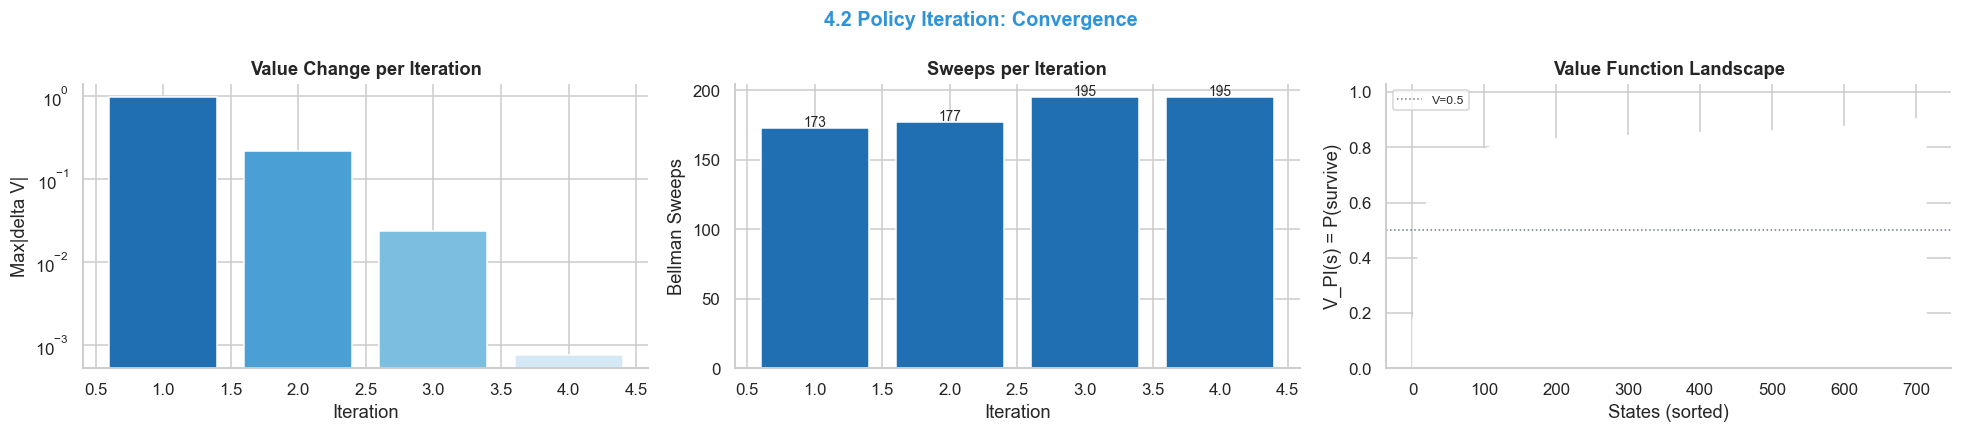

In [30]:
fig,axes=plt.subplots(1,3,figsize=(18,4))
fig.suptitle('4.2 Policy Iteration: Convergence',fontsize=13,fontweight='bold',color=H_COL)
vd=[np.max(np.abs(pi_hist_V[i+1]-pi_hist_V[i])) for i in range(len(pi_hist_V)-1)]
axes[0].bar(range(1,len(vd)+1),vd,color=[B2,B3,B4,B6][:len(vd)],edgecolor='white')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Max|delta V|')
axes[0].set_title('Value Change per Iteration',fontweight='bold'); axes[0].set_yscale('log')
axes[0].spines[['top','right']].set_visible(False)
axes[1].bar(range(1,len(pi_eval_iters)+1),pi_eval_iters,color=B2,edgecolor='white')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Bellman Sweeps')
axes[1].set_title('Sweeps per Iteration',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
for i,v in enumerate(pi_eval_iters): axes[1].text(i+1,v+1,str(v),ha='center',fontsize=9)
sv=np.sort(pi_V[:S-2])
axes[2].bar(range(len(sv)),sv,color=[plt.cm.Blues(0.15+0.85*v) for v in sv],width=1.0)
axes[2].axhline(0.5,color=B0,lw=1,ls=':',alpha=0.6,label='V=0.5')
axes[2].set_xlabel('States (sorted)'); axes[2].set_ylabel('V_PI(s) = P(survive)')
axes[2].set_title('Value Function Landscape',fontweight='bold')
axes[2].legend(fontsize=8); axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_4_conv.png',dpi=150,bbox_inches='tight'); plt.show()

## <font color='#2f94d7' size=6>**4.3 Evaluation**</font> <a class="anchor" id="4_3"></a>

[Back to TOC](#toc)

  [Policy Iteration] Ep 200/1000 | Survival: 74.5%
  [Policy Iteration] Ep 400/1000 | Survival: 74.8%
  [Policy Iteration] Ep 600/1000 | Survival: 77.0%
  [Policy Iteration] Ep 800/1000 | Survival: 79.6%
  [Policy Iteration] Ep 1000/1000 | Survival: 78.8%
  [Policy Iteration] Result: 78.8% (1000 episodes)


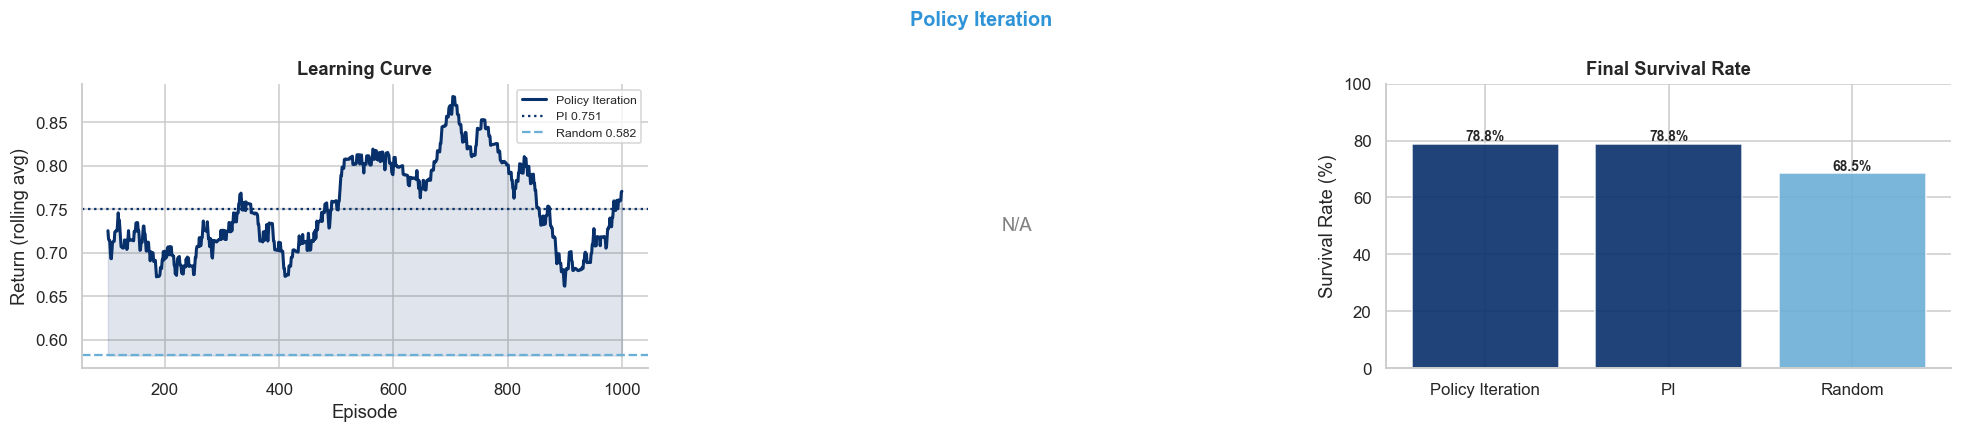

  Policy Iteration
  Survival Rate : 78.8% +/- 2.5%
  vs PI         : +0.0 pp
  vs Random     : +10.3 pp
PI: 78.8% +/- 2.5%  |  4 iter  |  740 sweeps  |  0.66s
PI: 78.8% | mean return: 0.7507


In [32]:
pi_returns,pi_lengths=evaluate_policy(pi_policy,n_episodes=1000,label='Policy Iteration')
pi_survival = float(np.mean(pi_returns > 0)) * 100
pi_surv_ci = 1.96 * np.sqrt((pi_survival / 100) * (1 - pi_survival / 100) / 1000) * 100

pi_mean_ret = float(np.mean(pi_returns))


rand_mean_ret = float(np.mean(rand_returns))

plot_results(
    study=None,
    train_returns=pi_returns,
    label='Policy Iteration',
    color=REF_PI,
    final_surv=pi_survival,
    pi_surv=pi_survival,
    rand_surv=rand_survival,
    pi_mean_ret=pi_mean_ret,
    rand_mean_ret=rand_mean_ret,
    plot_name='fig_4_pi'
)

print(
    f'PI: {pi_survival:.1f}% +/- {pi_surv_ci:.1f}%  |  '
    f'{len(pi_eval_iters)} iter  |  {sum(pi_eval_iters)} sweeps  |  {pi_time:.2f}s'
)

print(f'PI: {pi_survival:.1f}% | mean return: {pi_mean_ret:.4f}')

In [33]:
# ── Inject MDP globals into functions_ConfigA ────────────────────────────────
# Must run after Policy Iteration (pi_V, P_pi, R_shaped are available)
fa.configure(S, A, SEED, GAMMA, pi_V, P_pi, R_shaped)


  fa.configure: S=716, A=25, seed=42, gamma=1.0
  pi_V range: [0.0000, 0.9814]


# <font color='#2f94d7' size=6>**5. Dyna-Q with Prioritized Sweeping and Shaping**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**5.1 Rationale and Architecture**</font> <a class="anchor" id="5_1"></a>

[Back to TOC](#toc)

Dyna-Q combines real environment steps with k model-based planning steps, multiplying
Q-value updates by k+1 per episode. Prioritized Sweeping (PS) focuses planning on
state-action pairs with the highest absolute TD error, avoiding degradation at high k.
Reward shaping densifies the terminal-only signal. Together these three components
address the credit assignment bottleneck identified in Section 3.3.

**Hyperparameters optimised by Optuna:** alpha_start, alpha_end, alpha_decay, k, ps_theta, eps_decay.


## <font color='#2f94d7' size=6>**5.2 Algorithm Implementation**</font> <a class="anchor" id="5_2"></a>

[Back to TOC](#toc)

In [37]:
# train_dynaq_ps defined in functions_ConfigA.py
print('train_dynaq_ps defined.')


train_dynaq_ps defined.


## <font color='#2f94d7' size=6>**5.3 Optuna Hyperparameter Optimisation**</font> <a class="anchor" id="5_3"></a>

[Back to TOC](#toc)

In [39]:
def objective_dynaq(trial):
    params = dict(
        alpha_start = trial.suggest_float('alpha_start', 0.001, 0.5,     log=True),
        alpha_end   = trial.suggest_float('alpha_end',   0.0001, 0.05,   log=True),
        alpha_decay = trial.suggest_float('alpha_decay', 0.9990, 0.99999),
        k           = trial.suggest_int('k',             5, 100),
        ps_theta    = trial.suggest_float('ps_theta',    0.0005, 0.1,    log=True),
        eps_decay   = trial.suggest_float('eps_decay',   0.9990, 0.99999),
    )
    Q, _ = train_dynaq_ps(**params, n_episodes=TRIAL_EPS, verbose=False)
    return silent_eval(np.argmax(Q, axis=1), TRIAL_EVAL)

study_dq = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
t0_opt = time.time()
study_dq.optimize(
    objective_dynaq, n_trials=N_TRIALS,
    callbacks=[make_optuna_callback('Dyna-Q + PS + Shaping')]
)

print(f'Optuna complete: {time.time()-t0_opt:.0f}s  |  Best: {study_dq.best_value:.1f}%')
print(f'Best params: {study_dq.best_params}')

  [Dyna-Q + PS + Shaping] Trial  1/30 | Value: 75.7% | Best: 75.7%
  [Dyna-Q + PS + Shaping] Trial  2/30 | Value: 79.3% | Best: 79.3%
  [Dyna-Q + PS + Shaping] Trial  3/30 | Value: 75.7% | Best: 79.3%
  [Dyna-Q + PS + Shaping] Trial  4/30 | Value: 78.0% | Best: 79.3%
  [Dyna-Q + PS + Shaping] Trial  5/30 | Value: 77.7% | Best: 79.3%
  [Dyna-Q + PS + Shaping] Trial  6/30 | Value: 77.3% | Best: 79.3%
  [Dyna-Q + PS + Shaping] Trial  7/30 | Value: 78.3% | Best: 79.3%
  [Dyna-Q + PS + Shaping] Trial  8/30 | Value: 76.0% | Best: 79.3%
  [Dyna-Q + PS + Shaping] Trial  9/30 | Value: 79.3% | Best: 79.3%
  [Dyna-Q + PS + Shaping] Trial 10/30 | Value: 80.0% | Best: 80.0%
  [Dyna-Q + PS + Shaping] Trial 11/30 | Value: 77.0% | Best: 80.0%
  [Dyna-Q + PS + Shaping] Trial 12/30 | Value: 76.0% | Best: 80.0%
  [Dyna-Q + PS + Shaping] Trial 13/30 | Value: 78.0% | Best: 80.0%
  [Dyna-Q + PS + Shaping] Trial 14/30 | Value: 76.3% | Best: 80.0%
  [Dyna-Q + PS + Shaping] Trial 15/30 | Value: 75.7% | Best: 8

## <font color='#2f94d7' size=6>**5.4 Final Training and Evaluation**</font> <a class="anchor" id="5_4"></a>

[Back to TOC](#toc)

  [Dyna-Q+PS] Ep   5000/60000 | alpha: 0.03077 | eps: 0.03368 | Surv(500): 84.2% | 17s
  [Dyna-Q+PS] Ep  10000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 81.0% | 34s
  [Dyna-Q+PS] Ep  15000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 80.2% | 52s
  [Dyna-Q+PS] Ep  20000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 84.2% | 69s
  [Dyna-Q+PS] Ep  25000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 79.4% | 87s
  [Dyna-Q+PS] Ep  30000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 77.8% | 104s
  [Dyna-Q+PS] Ep  35000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 81.4% | 120s
  [Dyna-Q+PS] Ep  40000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 79.8% | 138s
  [Dyna-Q+PS] Ep  45000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 80.4% | 155s
  [Dyna-Q+PS] Ep  50000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 82.4% | 171s
  [Dyna-Q+PS] Ep  55000/60000 | alpha: 0.03077 | eps: 0.00500 | Surv(500): 81.4% | 188s
  [Dyna-Q+PS] Ep  60000/60000 | alpha

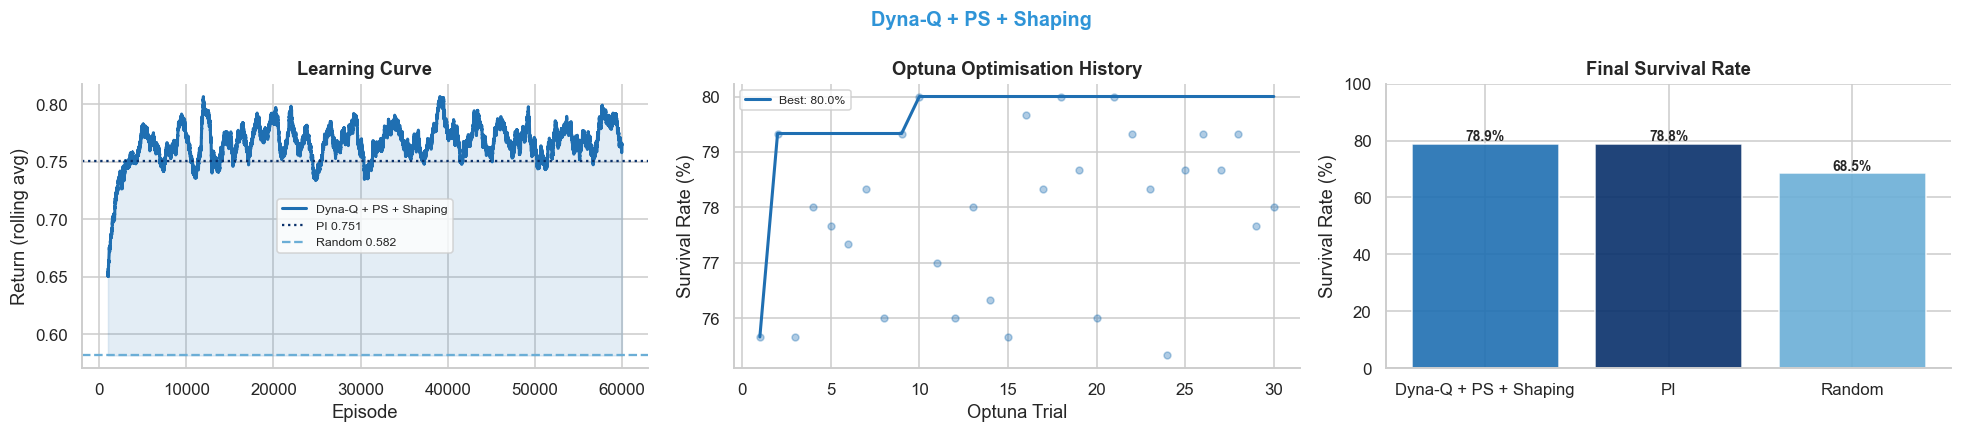

  Dyna-Q + PS + Shaping
  Survival Rate : 78.9% +/- 2.5%
  vs PI         : +0.1 pp
  vs Random     : +10.4 pp
  Best Optuna   : 80.0%
  Best params   : {'alpha_start': 0.041087915453240795, 'alpha_end': 0.0307688247430154, 'alpha_decay': 0.9990876075770314, 'k': 23, 'ps_theta': 0.0006353885037249847, 'eps_decay': 0.9993220770274557}


In [41]:
final_params_dq = dict(study_dq.best_params)
final_params_dq['alpha_start'] = min(final_params_dq['alpha_start'], 0.15)

Q_dq, dq_returns = train_dynaq_ps(
    **final_params_dq,
    n_episodes=60_000,
    verbose=True
)

dq_policy   = np.argmax(Q_dq, axis=1)
dq_eval_r, dq_eval_l = evaluate_policy(dq_policy, label='Dyna-Q+PS+Shaping')
dq_survival  = float(np.mean(dq_eval_r > 0)) * 100
dq_surv_ci   = 1.96 * np.sqrt((dq_survival/100)*(1-dq_survival/100)/1000) * 100
dq_coverage  = np.sum(Q_dq[:S-2] != 0) / ((S-2)*A) * 100
agreement_dq = (pi_policy[:714] == dq_policy[:714]).mean() * 100

plot_results(study_dq, dq_returns, 'Dyna-Q + PS + Shaping', C_DQ,
             dq_survival, pi_survival, rand_survival,
             pi_mean_ret, rand_mean_ret, 'fig_5_dynaq')

# <font color='#2f94d7' size=6>**6. Candidate Algorithms**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

Each candidate follows the same three-cell pattern:

1. **train_ALGO():** defines the algorithm once, used by both Optuna and final training
2. **Optuna:** calls train_ALGO 50 times (50k episodes each) to find best hyperparameters
3. **Final training:** calls train_ALGO with best params and full episode count (verbose)

All algorithms use the same R_shaped matrix computed from V_PI in Section 4.


## <font color='#2f94d7' size=6>**6.1 Expected SARSA with Eligibility Traces and Shaping**</font> <a class="anchor" id="6_1"></a>

[Back to TOC](#toc)

Expected SARSA replaces the sampled next-action value with the expected value over
the full action distribution under epsilon-greedy policy:
E[Q(s',a')] = (1-eps)*max Q(s',a') + (eps/|A|)*sum Q(s',a')
This reduces variance versus SARSA and eliminates maximisation bias versus Q-Learning.
Combined with eligibility traces (lambda) and reward shaping. Not in course curriculum.


In [44]:
# train_expected_sarsa defined in functions_ConfigA.py
def objective_esarsa(trial):
    p=dict(alpha_start=trial.suggest_float('alpha_start',0.001,0.5,log=True),
           alpha_end  =trial.suggest_float('alpha_end',0.0001,0.05,log=True),
           alpha_decay=trial.suggest_float('alpha_decay',0.9990,0.99999),
           lam        =trial.suggest_float('lambda',0.1,0.95),
           eps_decay  =trial.suggest_float('eps_decay',0.9990,0.99999))
    Q,_=train_expected_sarsa(**p,n_episodes=TRIAL_EPS,verbose=False)
    return silent_eval(np.argmax(Q,axis=1),TRIAL_EVAL)

study_es=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
study_es.optimize(objective_esarsa,n_trials=N_TRIALS,callbacks=[make_optuna_callback('Expected SARSA(lam)+Shaping')])
print(f'Best: {study_es.best_value:.1f}%  |  {study_es.best_params}')

  [Expected SARSA(lam)+Shaping] Trial  1/30 | Value: 67.0% | Best: 67.0%
  [Expected SARSA(lam)+Shaping] Trial  2/30 | Value: 72.3% | Best: 72.3%
  [Expected SARSA(lam)+Shaping] Trial  3/30 | Value: 75.3% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial  4/30 | Value: 66.7% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial  5/30 | Value: 72.0% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial  6/30 | Value: 71.0% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial  7/30 | Value: 67.0% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial  8/30 | Value: 70.3% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial  9/30 | Value: 69.7% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial 10/30 | Value: 69.3% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial 11/30 | Value: 71.3% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial 12/30 | Value: 69.7% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial 13/30 | Value: 72.7% | Best: 75.3%
  [Expected SARSA(lam)+Shaping] Trial 14/30 | Value

  [ExpSARSA] Ep   5000/100000 | alpha: 0.04147 | eps: 0.01655 | Surv(500): 73.2% | 1s
  [ExpSARSA] Ep  10000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 76.4% | 3s
  [ExpSARSA] Ep  15000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 71.6% | 4s
  [ExpSARSA] Ep  20000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 75.2% | 5s
  [ExpSARSA] Ep  25000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 79.2% | 7s
  [ExpSARSA] Ep  30000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 74.0% | 8s
  [ExpSARSA] Ep  35000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 74.0% | 9s
  [ExpSARSA] Ep  40000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 79.6% | 11s
  [ExpSARSA] Ep  45000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 75.4% | 12s
  [ExpSARSA] Ep  50000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 74.2% | 13s
  [ExpSARSA] Ep  55000/100000 | alpha: 0.04147 | eps: 0.00500 | Surv(500): 75.6% | 15s
  [ExpSARSA] Ep  60000/100000 | alpha: 0.04147 | e

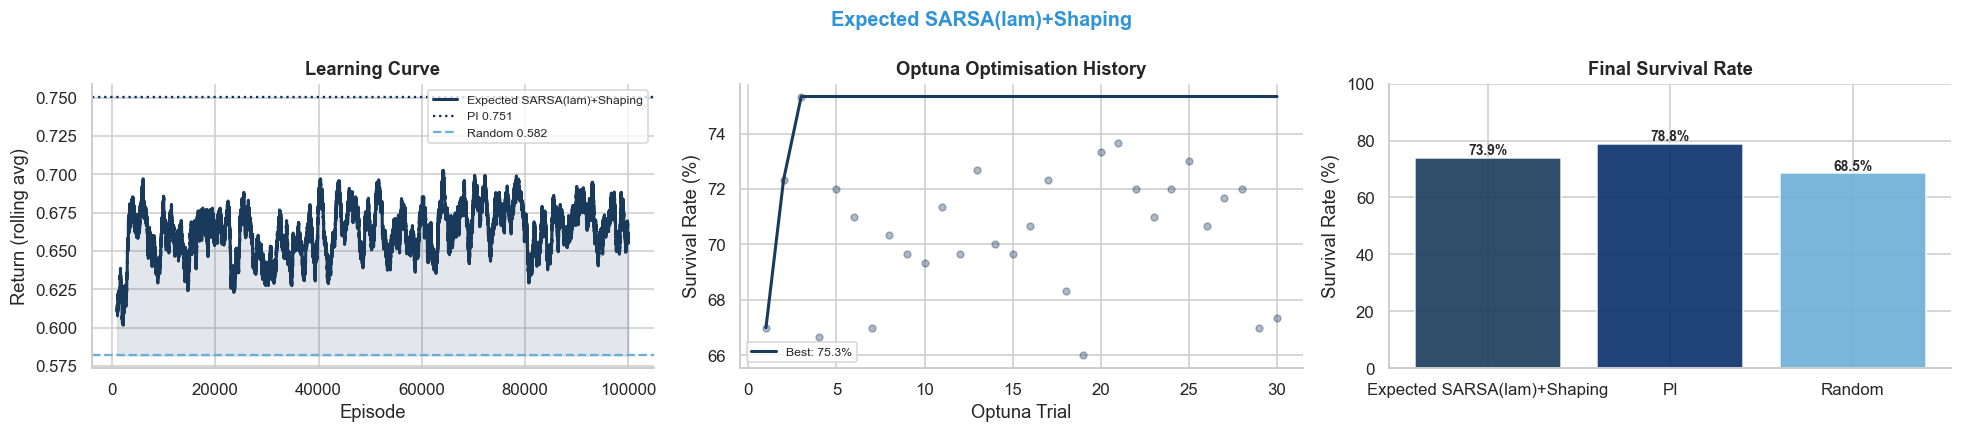

  Expected SARSA(lam)+Shaping
  Survival Rate : 73.9% +/- 2.7%
  vs PI         : -4.9 pp
  vs Random     : +5.4 pp
  Best Optuna   : 75.3%
  Best params   : {'alpha_start': 0.001136467270001117, 'alpha_end': 0.04147225000481639, 'alpha_decay': 0.9998241182143924, 'lambda': 0.2804882440765347, 'eps_decay': 0.999180006717535}


In [45]:
es_params = dict(study_es.best_params)
es_params['lam'] = es_params.pop('lambda')

es_params['alpha_start'] = min(es_params['alpha_start'], 0.15)

Q_es, es_returns = train_expected_sarsa(**es_params, n_episodes=100_000, verbose=True)
es_policy    = np.argmax(Q_es, axis=1)
es_eval_r, _ = evaluate_policy(es_policy, label='ExpSARSA+Shap ')
es_survival  = float(np.mean(es_eval_r > 0)) * 100
es_surv_ci   = 1.96 * np.sqrt((es_survival/100)*(1-es_survival/100)/1000) * 100
es_coverage  = np.sum(Q_es[:S-2] != 0) / ((S-2)*A) * 100
agreement_es = (pi_policy[:714] == es_policy[:714]).mean() * 100
plot_results(study_es, es_returns, 'Expected SARSA(lam)+Shaping', C_ES,
             es_survival, pi_survival, rand_survival,
             pi_mean_ret, rand_mean_ret, 'fig_6_1_es')

## <font color='#2f94d7' size=6>**6.2 Q-Learning with Learning Rate Decay and Shaping**</font> <a class="anchor" id="6_2"></a>

[Back to TOC](#toc)

Off-policy TD(0) benchmark. Alpha decay (alpha_start to alpha_end) ensures stable late
convergence. Reward shaping addresses the credit assignment bottleneck.


In [47]:
# train_qlearning defined in functions_ConfigA.py
def objective_ql(trial):
    p=dict(alpha_start=trial.suggest_float('alpha_start',0.001,0.5,log=True),
           alpha_end  =trial.suggest_float('alpha_end',0.0001,0.05,log=True),
           alpha_decay=trial.suggest_float('alpha_decay',0.9990,0.99999),
           eps_decay  =trial.suggest_float('eps_decay',0.9990,0.99999))
    Q,_=train_qlearning(**p,n_episodes=TRIAL_EPS,verbose=False)
    return silent_eval(np.argmax(Q,axis=1),TRIAL_EVAL)

study_ql=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
study_ql.optimize(objective_ql,n_trials=N_TRIALS,callbacks=[make_optuna_callback('Q-Learning+Shaping')])
print(f'Best: {study_ql.best_value:.1f}%  |  {study_ql.best_params}')

  [Q-Learning+Shaping] Trial  1/30 | Value: 72.0% | Best: 72.0%
  [Q-Learning+Shaping] Trial  2/30 | Value: 69.3% | Best: 72.0%
  [Q-Learning+Shaping] Trial  3/30 | Value: 72.7% | Best: 72.7%
  [Q-Learning+Shaping] Trial  4/30 | Value: 71.0% | Best: 72.7%
  [Q-Learning+Shaping] Trial  5/30 | Value: 71.3% | Best: 72.7%
  [Q-Learning+Shaping] Trial  6/30 | Value: 72.0% | Best: 72.7%
  [Q-Learning+Shaping] Trial  7/30 | Value: 73.3% | Best: 73.3%
  [Q-Learning+Shaping] Trial  8/30 | Value: 72.0% | Best: 73.3%
  [Q-Learning+Shaping] Trial  9/30 | Value: 71.3% | Best: 73.3%
  [Q-Learning+Shaping] Trial 10/30 | Value: 74.0% | Best: 74.0%
  [Q-Learning+Shaping] Trial 11/30 | Value: 75.3% | Best: 75.3%
  [Q-Learning+Shaping] Trial 12/30 | Value: 73.7% | Best: 75.3%
  [Q-Learning+Shaping] Trial 13/30 | Value: 73.0% | Best: 75.3%
  [Q-Learning+Shaping] Trial 14/30 | Value: 72.0% | Best: 75.3%
  [Q-Learning+Shaping] Trial 15/30 | Value: 76.3% | Best: 76.3%
  [Q-Learning+Shaping] Trial 16/30 | Val

  [Q-Learning] Ep   5000/150000 | alpha: 0.06592 | eps: 0.08130 | Surv(500): 76.2% | 1s
  [Q-Learning] Ep  10000/150000 | alpha: 0.02896 | eps: 0.00661 | Surv(500): 76.2% | 2s
  [Q-Learning] Ep  15000/150000 | alpha: 0.01273 | eps: 0.00500 | Surv(500): 71.8% | 2s
  [Q-Learning] Ep  20000/150000 | alpha: 0.00559 | eps: 0.00500 | Surv(500): 76.6% | 3s
  [Q-Learning] Ep  25000/150000 | alpha: 0.00246 | eps: 0.00500 | Surv(500): 76.2% | 4s
  [Q-Learning] Ep  30000/150000 | alpha: 0.00108 | eps: 0.00500 | Surv(500): 75.8% | 4s
  [Q-Learning] Ep  35000/150000 | alpha: 0.00047 | eps: 0.00500 | Surv(500): 78.4% | 5s
  [Q-Learning] Ep  40000/150000 | alpha: 0.00045 | eps: 0.00500 | Surv(500): 76.4% | 6s
  [Q-Learning] Ep  45000/150000 | alpha: 0.00045 | eps: 0.00500 | Surv(500): 78.6% | 7s
  [Q-Learning] Ep  50000/150000 | alpha: 0.00045 | eps: 0.00500 | Surv(500): 80.8% | 8s
  [Q-Learning] Ep  55000/150000 | alpha: 0.00045 | eps: 0.00500 | Surv(500): 80.0% | 8s
  [Q-Learning] Ep  60000/150000 

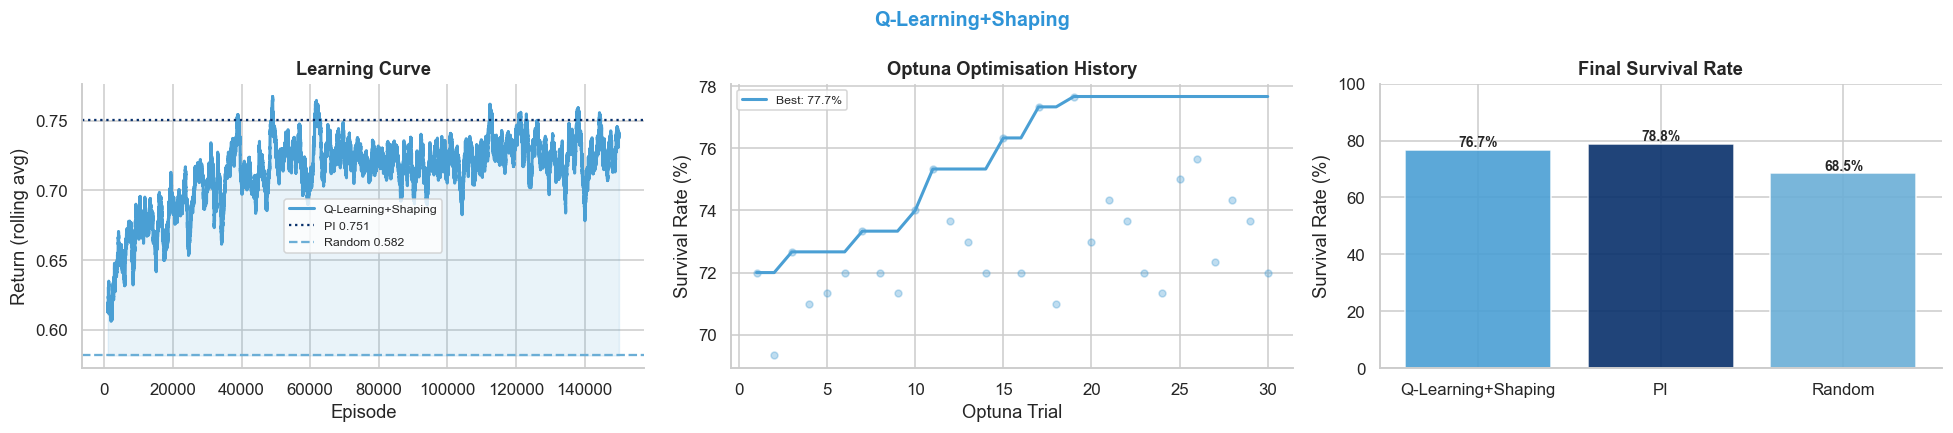

  Q-Learning+Shaping
  Survival Rate : 76.7% +/- 2.6%
  vs PI         : -2.1 pp
  vs Random     : +8.2 pp
  Best Optuna   : 77.7%
  Best params   : {'alpha_start': 0.19221547706038125, 'alpha_end': 0.0004486932317344336, 'alpha_decay': 0.9998355403006941, 'eps_decay': 0.9994981926246096}


In [48]:
final_params_ql = dict(study_ql.best_params)
final_params_ql['alpha_start'] = min(final_params_ql['alpha_start'], 0.15)
Q_ql,ql_returns=train_qlearning(**final_params_ql,n_episodes=150_000,verbose=True)
ql_policy=np.argmax(Q_ql,axis=1)
ql_eval_r,_=evaluate_policy(ql_policy,label='Q-Learn+Shap  ')
ql_survival=float(np.mean(ql_eval_r>0))*100
ql_surv_ci =1.96*np.sqrt((ql_survival/100)*(1-ql_survival/100)/1000)*100
ql_coverage=np.sum(Q_ql[:S-2]!=0)/((S-2)*A)*100
agreement_ql=(pi_policy[:714]==ql_policy[:714]).mean()*100
plot_results(study_ql,ql_returns,'Q-Learning+Shaping',C_QL,ql_survival,pi_survival,rand_survival,
             pi_mean_ret, rand_mean_ret,'fig_6_2_ql')

## <font color='#2f94d7' size=6>**6.3 SARSA with Eligibility Traces and Shaping**</font> <a class="anchor" id="6_3"></a>

[Back to TOC](#toc)

On-policy TD(lambda). Uses the actual next action taken (not max), making it more stable
with eligibility traces than Q(lambda). Lambda controls trace decay.


In [50]:
# train_sarsa defined in functions_ConfigA.py
def objective_sar(trial):
    p=dict(alpha_start=trial.suggest_float('alpha_start',0.001,0.5,log=True),
           alpha_end  =trial.suggest_float('alpha_end',0.0001,0.05,log=True),
           alpha_decay=trial.suggest_float('alpha_decay',0.9990,0.99999),
           lam        =trial.suggest_float('lambda',0.1,0.95),
           eps_decay  =trial.suggest_float('eps_decay',0.9990,0.99999))
    Q,_=train_sarsa(**p,n_episodes=TRIAL_EPS,verbose=False)
    return silent_eval(np.argmax(Q,axis=1),TRIAL_EVAL)

study_sar=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
study_sar.optimize(objective_sar,n_trials=N_TRIALS,callbacks=[make_optuna_callback('SARSA(lam)+Shaping')])
print(f'Best: {study_sar.best_value:.1f}%  |  {study_sar.best_params}')

  [SARSA(lam)+Shaping] Trial  1/30 | Value: 69.0% | Best: 69.0%
  [SARSA(lam)+Shaping] Trial  2/30 | Value: 70.7% | Best: 70.7%
  [SARSA(lam)+Shaping] Trial  3/30 | Value: 68.0% | Best: 70.7%
  [SARSA(lam)+Shaping] Trial  4/30 | Value: 65.3% | Best: 70.7%
  [SARSA(lam)+Shaping] Trial  5/30 | Value: 69.7% | Best: 70.7%
  [SARSA(lam)+Shaping] Trial  6/30 | Value: 68.3% | Best: 70.7%
  [SARSA(lam)+Shaping] Trial  7/30 | Value: 67.7% | Best: 70.7%
  [SARSA(lam)+Shaping] Trial  8/30 | Value: 67.7% | Best: 70.7%
  [SARSA(lam)+Shaping] Trial  9/30 | Value: 65.0% | Best: 70.7%
  [SARSA(lam)+Shaping] Trial 10/30 | Value: 69.0% | Best: 70.7%
  [SARSA(lam)+Shaping] Trial 11/30 | Value: 74.0% | Best: 74.0%
  [SARSA(lam)+Shaping] Trial 12/30 | Value: 72.3% | Best: 74.0%
  [SARSA(lam)+Shaping] Trial 13/30 | Value: 75.7% | Best: 75.7%
  [SARSA(lam)+Shaping] Trial 14/30 | Value: 72.0% | Best: 75.7%
  [SARSA(lam)+Shaping] Trial 15/30 | Value: 69.3% | Best: 75.7%
  [SARSA(lam)+Shaping] Trial 16/30 | Val

  [SARSA] Ep   5000/100000 | alpha: 0.00762 | eps: 0.35198 | Surv(500): 72.8% | 1s
  [SARSA] Ep  10000/100000 | alpha: 0.00636 | eps: 0.12389 | Surv(500): 73.0% | 2s
  [SARSA] Ep  15000/100000 | alpha: 0.00531 | eps: 0.04361 | Surv(500): 77.2% | 4s
  [SARSA] Ep  20000/100000 | alpha: 0.00443 | eps: 0.01535 | Surv(500): 72.4% | 5s
  [SARSA] Ep  25000/100000 | alpha: 0.00370 | eps: 0.00540 | Surv(500): 74.4% | 6s
  [SARSA] Ep  30000/100000 | alpha: 0.00309 | eps: 0.00500 | Surv(500): 74.4% | 7s
  [SARSA] Ep  35000/100000 | alpha: 0.00258 | eps: 0.00500 | Surv(500): 74.6% | 8s
  [SARSA] Ep  40000/100000 | alpha: 0.00215 | eps: 0.00500 | Surv(500): 74.2% | 10s
  [SARSA] Ep  45000/100000 | alpha: 0.00180 | eps: 0.00500 | Surv(500): 74.8% | 11s
  [SARSA] Ep  50000/100000 | alpha: 0.00150 | eps: 0.00500 | Surv(500): 79.2% | 12s
  [SARSA] Ep  55000/100000 | alpha: 0.00125 | eps: 0.00500 | Surv(500): 76.6% | 13s
  [SARSA] Ep  60000/100000 | alpha: 0.00104 | eps: 0.00500 | Surv(500): 79.4% | 14s

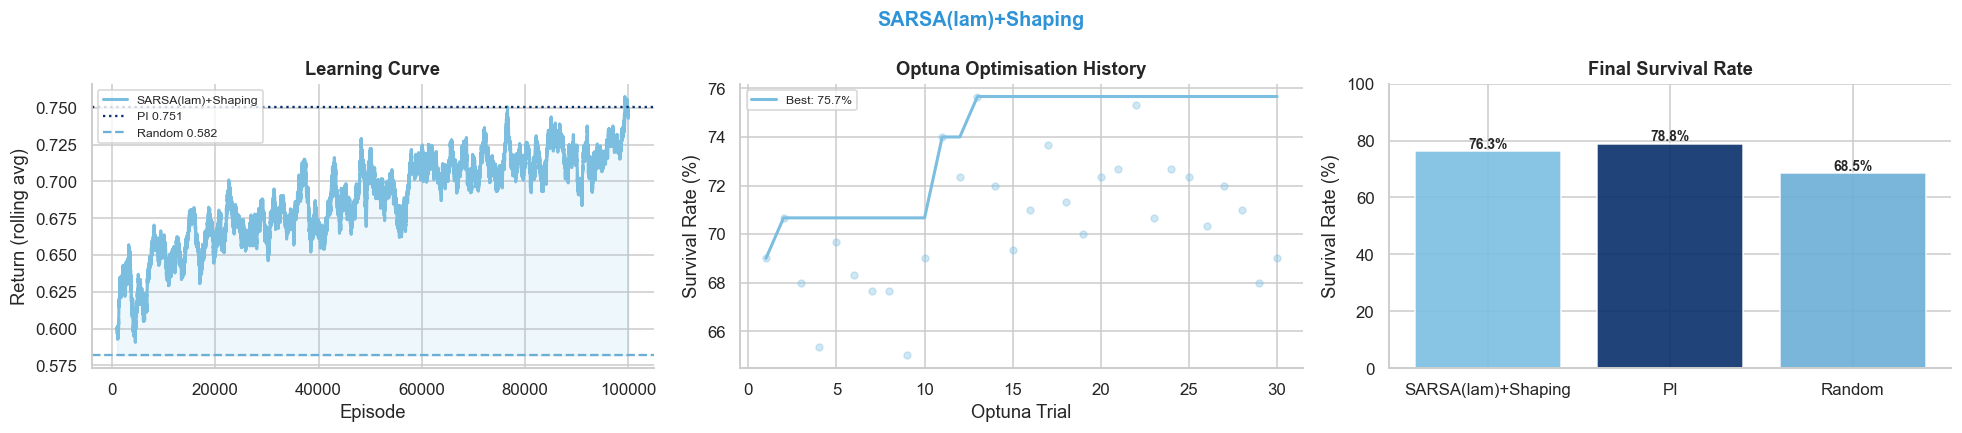

  SARSA(lam)+Shaping
  Survival Rate : 76.3% +/- 2.6%
  vs PI         : -2.5 pp
  vs Random     : +7.8 pp
  Best Optuna   : 75.7%
  Best params   : {'alpha_start': 0.009130066691160685, 'alpha_end': 0.00010292857916211857, 'alpha_decay': 0.9999638549496049, 'lambda': 0.128679992392536, 'eps_decay': 0.9997911840633109}


In [51]:
sar_params = dict(study_sar.best_params)
sar_params['lam'] = sar_params.pop('lambda')

sar_params['alpha_start'] = min(sar_params['alpha_start'], 0.15)
Q_sar, sar_returns = train_sarsa(**sar_params, n_episodes=100_000, verbose=True)
sar_policy=np.argmax(Q_sar,axis=1)
sar_eval_r,_=evaluate_policy(sar_policy,label='SARSA(lam)+Sh ')
sar_survival=float(np.mean(sar_eval_r>0))*100
sar_surv_ci =1.96*np.sqrt((sar_survival/100)*(1-sar_survival/100)/1000)*100
sar_coverage=np.sum(Q_sar[:S-2]!=0)/((S-2)*A)*100
agreement_sar=(pi_policy[:714]==sar_policy[:714]).mean()*100
plot_results(study_sar,sar_returns,'SARSA(lam)+Shaping',C_SAR,sar_survival,pi_survival,rand_survival,pi_mean_ret,rand_mean_ret,'fig_6_3_sar')

## <font color='#2f94d7' size=6>**6.4 Double Q-Learning and Shaping**</font> <a class="anchor" id="6_4"></a>

[Back to TOC](#toc)

Lecture 5 algorithm. Two Q-tables decouple action selection from evaluation, eliminating
maximisation bias. Behaviour policy uses Q_A + Q_B; one table is updated at random each step.


In [53]:
# train_double_ql defined in functions_ConfigA.py
def objective_dql(trial):
    p=dict(alpha_start=trial.suggest_float('alpha_start',0.001,0.5,log=True),
           alpha_end  =trial.suggest_float('alpha_end',0.0001,0.05,log=True),
           alpha_decay=trial.suggest_float('alpha_decay',0.9990,0.99999),
           eps_decay  =trial.suggest_float('eps_decay',0.9990,0.99999))
    (QA,QB),_=train_double_ql(**p,n_episodes=TRIAL_EPS,verbose=False)
    return silent_eval(np.argmax(QA+QB,axis=1),TRIAL_EVAL)

study_dql=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
study_dql.optimize(objective_dql,n_trials=N_TRIALS,callbacks=[make_optuna_callback('Double Q-Learning+Shaping')])
print(f'Best: {study_dql.best_value:.1f}%  |  {study_dql.best_params}')


  [Double Q-Learning+Shaping] Trial  1/30 | Value: 68.3% | Best: 68.3%
  [Double Q-Learning+Shaping] Trial  2/30 | Value: 72.7% | Best: 72.7%
  [Double Q-Learning+Shaping] Trial  3/30 | Value: 71.3% | Best: 72.7%
  [Double Q-Learning+Shaping] Trial  4/30 | Value: 69.3% | Best: 72.7%
  [Double Q-Learning+Shaping] Trial  5/30 | Value: 74.7% | Best: 74.7%
  [Double Q-Learning+Shaping] Trial  6/30 | Value: 71.0% | Best: 74.7%
  [Double Q-Learning+Shaping] Trial  7/30 | Value: 68.0% | Best: 74.7%
  [Double Q-Learning+Shaping] Trial  8/30 | Value: 68.7% | Best: 74.7%
  [Double Q-Learning+Shaping] Trial  9/30 | Value: 66.7% | Best: 74.7%
  [Double Q-Learning+Shaping] Trial 10/30 | Value: 76.3% | Best: 76.3%
  [Double Q-Learning+Shaping] Trial 11/30 | Value: 65.7% | Best: 76.3%
  [Double Q-Learning+Shaping] Trial 12/30 | Value: 72.3% | Best: 76.3%
  [Double Q-Learning+Shaping] Trial 13/30 | Value: 70.3% | Best: 76.3%
  [Double Q-Learning+Shaping] Trial 14/30 | Value: 74.3% | Best: 76.3%
  [Dou

  [Double-QL] Ep   5000/150000 | alpha: 0.00132 | eps: 0.05948 | Surv(500): 76.8% | 1s
  [Double-QL] Ep  10000/150000 | alpha: 0.00026 | eps: 0.00500 | Surv(500): 78.0% | 1s
  [Double-QL] Ep  15000/150000 | alpha: 0.00018 | eps: 0.00500 | Surv(500): 73.8% | 2s
  [Double-QL] Ep  20000/150000 | alpha: 0.00018 | eps: 0.00500 | Surv(500): 74.4% | 3s
  [Double-QL] Ep  25000/150000 | alpha: 0.00018 | eps: 0.00500 | Surv(500): 74.0% | 3s
  [Double-QL] Ep  30000/150000 | alpha: 0.00018 | eps: 0.00500 | Surv(500): 80.4% | 4s
  [Double-QL] Ep  35000/150000 | alpha: 0.00018 | eps: 0.00500 | Surv(500): 75.2% | 5s
  [Double-QL] Ep  40000/150000 | alpha: 0.00018 | eps: 0.00500 | Surv(500): 78.8% | 6s
  [Double-QL] Ep  45000/150000 | alpha: 0.00018 | eps: 0.00500 | Surv(500): 77.8% | 6s
  [Double-QL] Ep  50000/150000 | alpha: 0.00018 | eps: 0.00500 | Surv(500): 77.6% | 7s
  [Double-QL] Ep  55000/150000 | alpha: 0.00018 | eps: 0.00500 | Surv(500): 76.6% | 8s
  [Double-QL] Ep  60000/150000 | alpha: 0.0

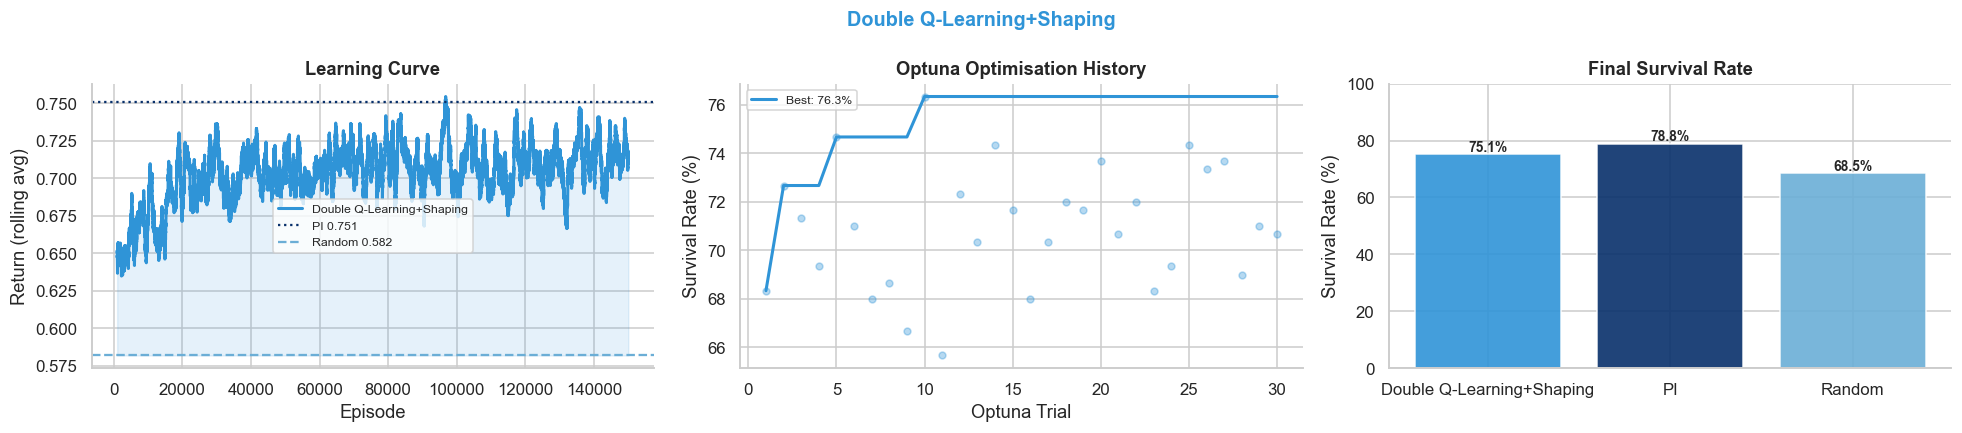

  Double Q-Learning+Shaping
  Survival Rate : 75.1% +/- 2.7%
  vs PI         : -3.7 pp
  vs Random     : +6.6 pp
  Best Optuna   : 76.3%
  Best params   : {'alpha_start': 0.00663962307985946, 'alpha_end': 0.00018349072049055458, 'alpha_decay': 0.9996773906962471, 'eps_decay': 0.9994357509688022}


In [54]:
final_params_dql = dict(study_dql.best_params)
final_params_dql['alpha_start'] = min(final_params_dql['alpha_start'], 0.15)
(Q_dqlA,Q_dqlB),dql_returns=train_double_ql(**final_params_dql,n_episodes=150_000,verbose=True)
dql_policy=np.argmax(Q_dqlA+Q_dqlB,axis=1)
dql_eval_r,_=evaluate_policy(dql_policy,label='DoubleQL+Shap ')
dql_survival=float(np.mean(dql_eval_r>0))*100
dql_surv_ci =1.96*np.sqrt((dql_survival/100)*(1-dql_survival/100)/1000)*100
dql_coverage=np.sum((Q_dqlA[:S-2]+Q_dqlB[:S-2])!=0)/((S-2)*A)*100
agreement_dql=(pi_policy[:714]==dql_policy[:714]).mean()*100
plot_results(study_dql,dql_returns,'Double Q-Learning+Shaping',C_DQL,dql_survival,pi_survival,rand_survival,
             pi_mean_ret, rand_mean_ret,'fig_6_4_dql')

## <font color='#2f94d7' size=6>**6.5 Monte Carlo Control and Shaping**</font> <a class="anchor" id="6_5"></a>

[Back to TOC](#toc)

Lab 3 algorithm. Computes exact episode returns before updating, avoiding bootstrapping.
Reward shaping reduces the variance typical of MC in sparse-reward settings. First-visit MC.


In [56]:
# train_mc defined in functions_ConfigA.py
def objective_mc(trial):
    p=dict(eps_decay=trial.suggest_float('eps_decay',0.9990,0.99999),
           eps_end  =trial.suggest_float('eps_end',0.005,0.1))
    Q,_,_=train_mc(**p,n_episodes=TRIAL_EPS,verbose=False)
    return silent_eval(np.argmax(Q,axis=1),TRIAL_EVAL)

study_mc=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
study_mc.optimize(objective_mc,n_trials=N_TRIALS,callbacks=[make_optuna_callback('Monte Carlo+Shaping')])
print(f'Best: {study_mc.best_value:.1f}%  |  {study_mc.best_params}')

  [Monte Carlo+Shaping] Trial  1/30 | Value: 69.0% | Best: 69.0%
  [Monte Carlo+Shaping] Trial  2/30 | Value: 71.7% | Best: 71.7%
  [Monte Carlo+Shaping] Trial  3/30 | Value: 67.7% | Best: 71.7%
  [Monte Carlo+Shaping] Trial  4/30 | Value: 70.3% | Best: 71.7%
  [Monte Carlo+Shaping] Trial  5/30 | Value: 66.3% | Best: 71.7%
  [Monte Carlo+Shaping] Trial  6/30 | Value: 68.3% | Best: 71.7%
  [Monte Carlo+Shaping] Trial  7/30 | Value: 69.3% | Best: 71.7%
  [Monte Carlo+Shaping] Trial  8/30 | Value: 70.0% | Best: 71.7%
  [Monte Carlo+Shaping] Trial  9/30 | Value: 68.0% | Best: 71.7%
  [Monte Carlo+Shaping] Trial 10/30 | Value: 69.3% | Best: 71.7%
  [Monte Carlo+Shaping] Trial 11/30 | Value: 67.0% | Best: 71.7%
  [Monte Carlo+Shaping] Trial 12/30 | Value: 66.0% | Best: 71.7%
  [Monte Carlo+Shaping] Trial 13/30 | Value: 67.3% | Best: 71.7%
  [Monte Carlo+Shaping] Trial 14/30 | Value: 67.7% | Best: 71.7%
  [Monte Carlo+Shaping] Trial 15/30 | Value: 72.3% | Best: 72.3%
  [Monte Carlo+Shaping] T

  [MC] Ep   5000/150000 | eps: 0.20489 | Surv(500): 69.0% | 1s
  [MC] Ep  10000/150000 | eps: 0.06121 | Surv(500): 73.6% | 1s
  [MC] Ep  15000/150000 | eps: 0.06121 | Surv(500): 72.6% | 2s
  [MC] Ep  20000/150000 | eps: 0.06121 | Surv(500): 71.0% | 3s
  [MC] Ep  25000/150000 | eps: 0.06121 | Surv(500): 70.4% | 4s
  [MC] Ep  30000/150000 | eps: 0.06121 | Surv(500): 69.6% | 4s
  [MC] Ep  35000/150000 | eps: 0.06121 | Surv(500): 74.0% | 5s
  [MC] Ep  40000/150000 | eps: 0.06121 | Surv(500): 74.2% | 6s
  [MC] Ep  45000/150000 | eps: 0.06121 | Surv(500): 73.2% | 6s
  [MC] Ep  50000/150000 | eps: 0.06121 | Surv(500): 73.8% | 7s
  [MC] Ep  55000/150000 | eps: 0.06121 | Surv(500): 76.8% | 8s
  [MC] Ep  60000/150000 | eps: 0.06121 | Surv(500): 69.0% | 8s
  [MC] Ep  65000/150000 | eps: 0.06121 | Surv(500): 76.2% | 9s
  [MC] Ep  70000/150000 | eps: 0.06121 | Surv(500): 76.4% | 10s
  [MC] Ep  75000/150000 | eps: 0.06121 | Surv(500): 76.4% | 11s
  [MC] Ep  80000/150000 | eps: 0.06121 | Surv(500): 7

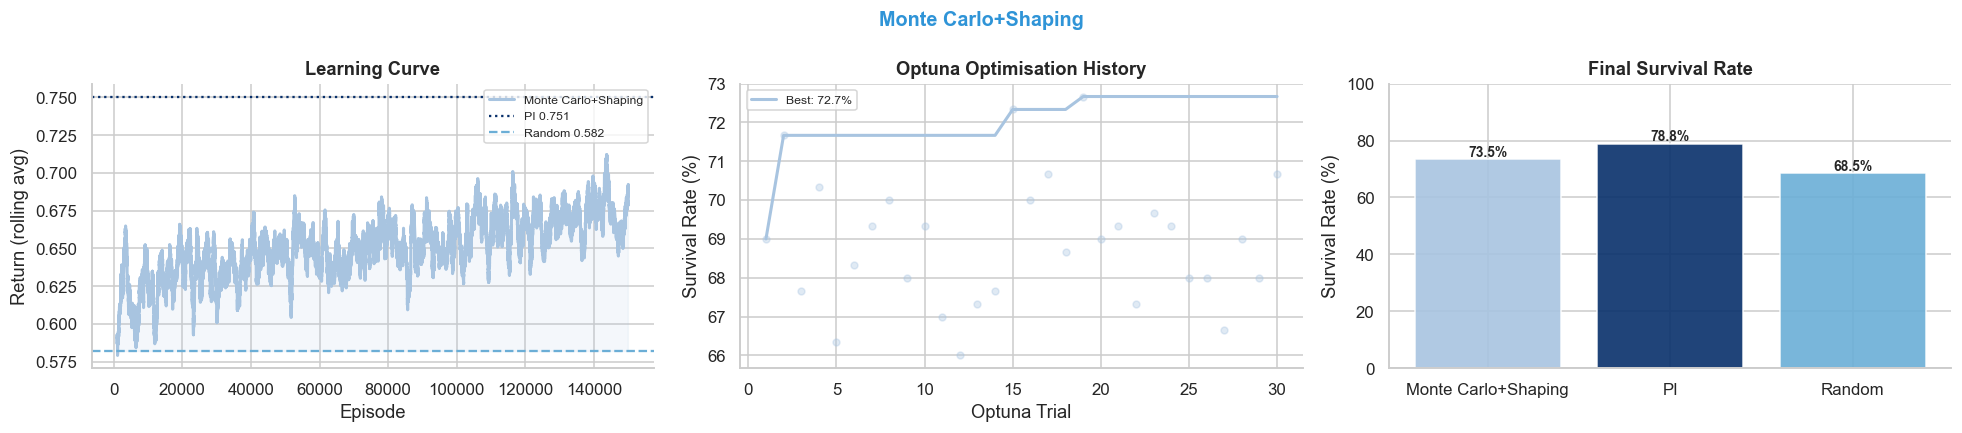

  Monte Carlo+Shaping
  Survival Rate : 73.5% +/- 2.7%
  vs PI         : -5.3 pp
  vs Random     : +5.0 pp
  Best Optuna   : 72.7%
  Best params   : {'eps_decay': 0.9996829915191162, 'eps_end': 0.06120994541335567}


In [57]:
Q_mc,mc_returns,mc_rc=train_mc(**study_mc.best_params,n_episodes=150_000,verbose=True)
mc_policy=np.argmax(Q_mc,axis=1)
mc_eval_r,_=evaluate_policy(mc_policy,label='MonteCarlo+Sh ')
mc_survival=float(np.mean(mc_eval_r>0))*100
mc_surv_ci =1.96*np.sqrt((mc_survival/100)*(1-mc_survival/100)/1000)*100
mc_coverage=np.sum(mc_rc[:S-2]>0)/((S-2)*A)*100
agreement_mc=(pi_policy[:714]==mc_policy[:714]).mean()*100
plot_results(study_mc,mc_returns,'Monte Carlo+Shaping',C_MC,mc_survival,pi_survival,rand_survival,
             pi_mean_ret, rand_mean_ret,'fig_6_5_mc')

## <font color='#2f94d7' size=6>**6.6 V-PI Warm-Start and Shaping**</font> <a class="anchor" id="6_6"></a>

[Back to TOC](#toc)

Lab 5 initialisation experiment extended: Q(s,a) = V_PI(s) for all actions as warm start.
The agent refines per-action distinctions via Q-Learning. eps_start is a hyperparameter
because the Q-table is already informative at episode 0.


In [59]:
# train_warmstart defined in functions_ConfigA.py
def objective_ws(trial):
    p=dict(alpha_start=trial.suggest_float('alpha_start',0.001,0.5,log=True),
           alpha_end  =trial.suggest_float('alpha_end',0.0001,0.05,log=True),
           alpha_decay=trial.suggest_float('alpha_decay',0.9990,0.99999),
           eps_start  =trial.suggest_float('eps_start',0.1,1.0),
           eps_decay  =trial.suggest_float('eps_decay',0.9990,0.99999))
    Q,_=train_warmstart(**p,n_episodes=TRIAL_EPS,verbose=False)
    return silent_eval(np.argmax(Q,axis=1),TRIAL_EVAL)

study_ws=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
study_ws.optimize(objective_ws,n_trials=N_TRIALS,callbacks=[make_optuna_callback('V_PI Warm-Start+Shaping')])
print(f'Best: {study_ws.best_value:.1f}%  |  {study_ws.best_params}')

  [V_PI Warm-Start+Shaping] Trial  1/30 | Value: 67.3% | Best: 67.3%
  [V_PI Warm-Start+Shaping] Trial  2/30 | Value: 72.7% | Best: 72.7%
  [V_PI Warm-Start+Shaping] Trial  3/30 | Value: 67.7% | Best: 72.7%
  [V_PI Warm-Start+Shaping] Trial  4/30 | Value: 74.3% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial  5/30 | Value: 70.3% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial  6/30 | Value: 72.3% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial  7/30 | Value: 69.0% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial  8/30 | Value: 67.7% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial  9/30 | Value: 70.7% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial 10/30 | Value: 69.3% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial 11/30 | Value: 69.0% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial 12/30 | Value: 72.0% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial 13/30 | Value: 69.0% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial 14/30 | Value: 71.0% | Best: 74.3%
  [V_PI Warm-Start+Shaping] Trial 

  [WarmStart] Ep   5000/100000 | alpha: 0.00066 | eps: 0.01390 | Surv(500): 72.0% | 1s
  [WarmStart] Ep  10000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 76.4% | 2s
  [WarmStart] Ep  15000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 71.6% | 2s
  [WarmStart] Ep  20000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 74.4% | 3s
  [WarmStart] Ep  25000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 73.6% | 4s
  [WarmStart] Ep  30000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 75.2% | 5s
  [WarmStart] Ep  35000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 72.0% | 6s
  [WarmStart] Ep  40000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 75.4% | 7s
  [WarmStart] Ep  45000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 75.0% | 7s
  [WarmStart] Ep  50000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 79.0% | 8s
  [WarmStart] Ep  55000/100000 | alpha: 0.00066 | eps: 0.00500 | Surv(500): 75.8% | 9s
  [WarmStart] Ep  60000/100000 | alpha: 0.0

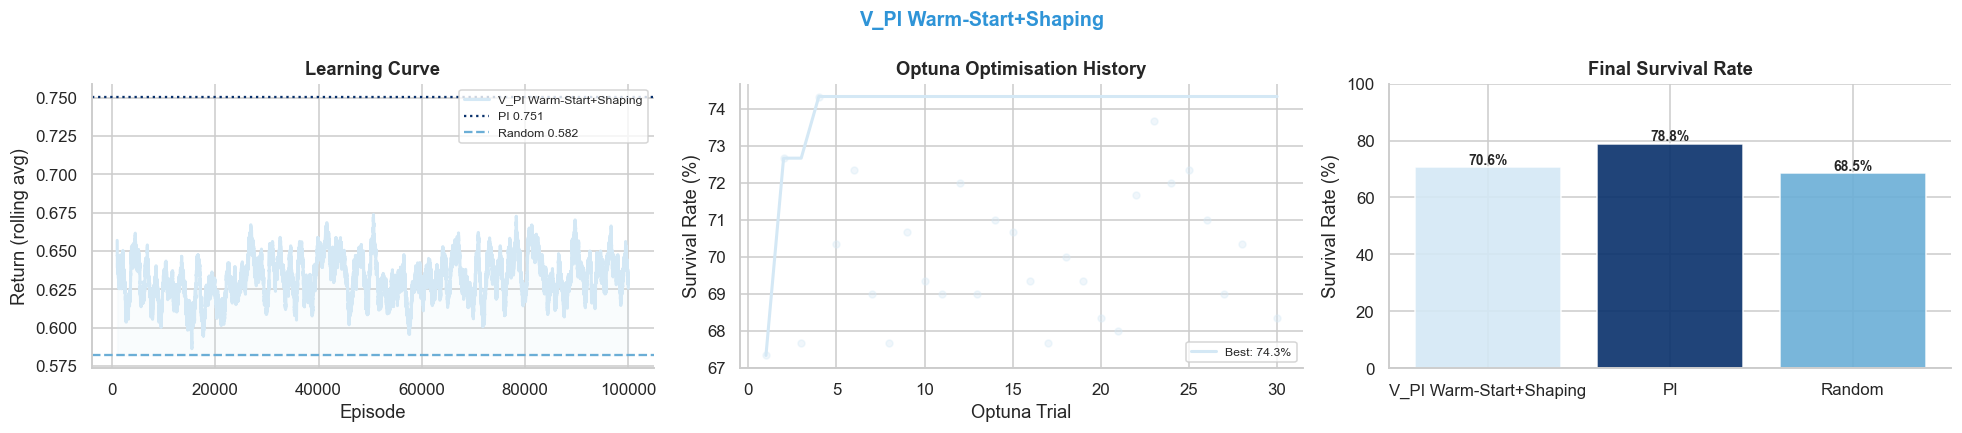

  V_PI Warm-Start+Shaping
  Survival Rate : 70.6% +/- 2.8%
  vs PI         : -8.2 pp
  vs Random     : +2.1 pp
  Best Optuna   : 74.3%
  Best params   : {'alpha_start': 0.0031261029103110596, 'alpha_end': 0.0006624310605949989, 'alpha_decay': 0.9995195088673159, 'eps_start': 0.4887505167779042, 'eps_decay': 0.999288316848796}


In [60]:
final_params_ws = dict(study_ws.best_params)
final_params_ws['alpha_start'] = min(final_params_ws['alpha_start'], 0.15)
Q_ws,ws_returns=train_warmstart(**final_params_ws,n_episodes=100_000,verbose=True)
ws_policy=np.argmax(Q_ws,axis=1)
ws_eval_r,_=evaluate_policy(ws_policy,label='WarmStart+Sh  ')
ws_survival=float(np.mean(ws_eval_r>0))*100
ws_surv_ci =1.96*np.sqrt((ws_survival/100)*(1-ws_survival/100)/1000)*100
ws_coverage=100.0
agreement_ws=(pi_policy[:714]==ws_policy[:714]).mean()*100
plot_results(study_ws,ws_returns,'V_PI Warm-Start+Shaping',C_WS,ws_survival,pi_survival,rand_survival,
             pi_mean_ret, rand_mean_ret,'fig_6_6_ws')

## <font color='#2f94d7' size=6>**6.7 Comparative Analysis and Algorithm Selection**</font> <a class="anchor" id="6_7"></a>

[Back to TOC](#toc)

All candidates ranked by survival rate. Policy Iteration is always selected as Algorithm 1
(model-based gold standard). The best model-free or hybrid algorithm is selected as
Algorithm 2. The comparison table quantifies what each algorithmic component contributes.


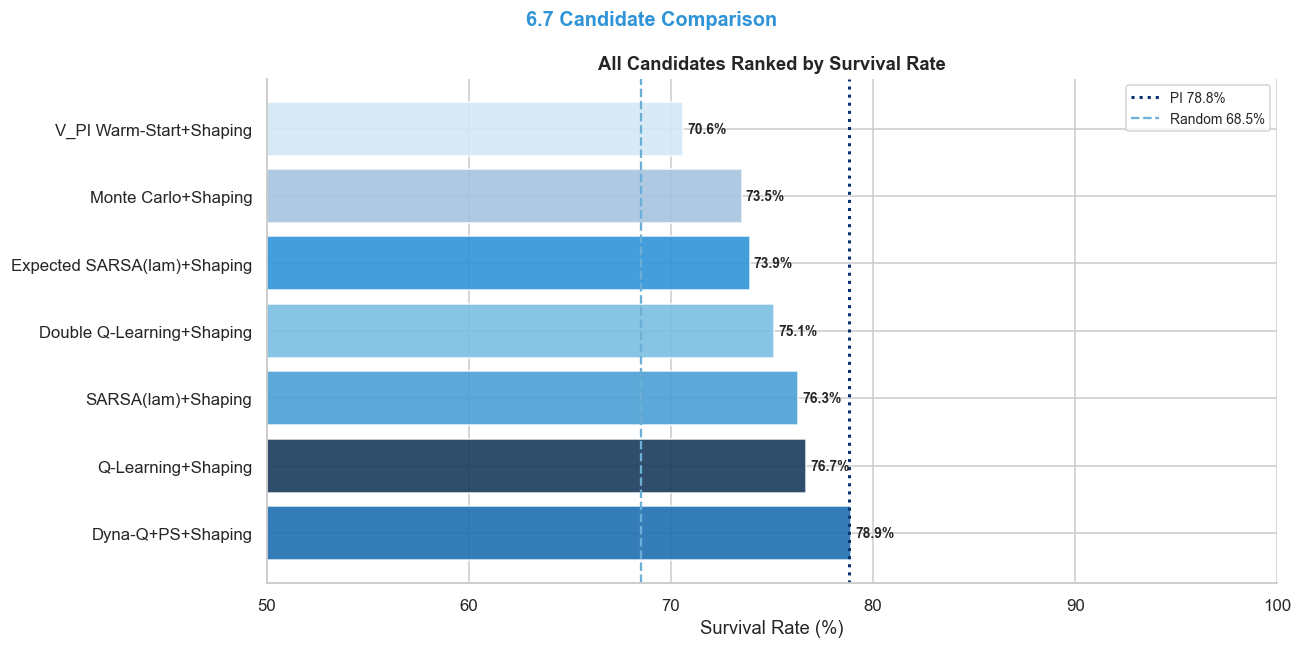

  Algorithm                                  Survival  vs Rand    vs PI   Agree PI
  Dyna-Q+PS+Shaping                             78.9%   +10.4pp    +0.1pp      57.1%
  Policy Iteration                              78.8%   +10.3pp    +0.0pp     100.0%
  Q-Learning+Shaping                            76.7%    +8.2pp    -2.1pp      36.8%
  SARSA(lam)+Shaping                            76.3%    +7.8pp    -2.5pp      34.2%
  Double Q-Learning+Shaping                     75.1%    +6.6pp    -3.7pp      30.1%
  Expected SARSA(lam)+Shaping                   73.9%    +5.4pp    -4.9pp      14.7%
  Monte Carlo+Shaping                           73.5%    +5.0pp    -5.3pp      11.2%
  V_PI Warm-Start+Shaping                       70.6%    +2.1pp    -8.2pp      11.2%

  SELECTED FOR REPORT:
    1. Policy Iteration  : 78.8%
    2. Dyna-Q+PS+Shaping             : 78.9%


In [62]:
candidates=[
    ('Policy Iteration',             pi_survival, 100.0,       100.0),
    ('Dyna-Q+PS+Shaping',            dq_survival, dq_coverage,  agreement_dq),
    ('Expected SARSA(lam)+Shaping',  es_survival, es_coverage,  agreement_es),
    ('Q-Learning+Shaping',           ql_survival, ql_coverage,  agreement_ql),
    ('SARSA(lam)+Shaping',           sar_survival,sar_coverage, agreement_sar),
    ('Double Q-Learning+Shaping',    dql_survival,dql_coverage, agreement_dql),
    ('Monte Carlo+Shaping',          mc_survival, mc_coverage,  agreement_mc),
    ('V_PI Warm-Start+Shaping',      ws_survival, ws_coverage,  agreement_ws),
]
fig,ax=plt.subplots(figsize=(12,6))
fig.suptitle('6.7 Candidate Comparison',fontsize=13,fontweight='bold',color=H_COL)
ranked=sorted(candidates[1:],key=lambda x:x[1],reverse=True)
cols=[C_DQ,C_ES,C_QL,C_SAR,C_DQL,C_MC,C_WS][:len(ranked)]
names=[r[0] for r in ranked]; vals=[r[1] for r in ranked]
bars=ax.barh(names,vals,color=cols,edgecolor='white',alpha=0.9)
ax.axvline(pi_survival,color=REF_PI,lw=2,ls=':',label=f'PI {pi_survival:.1f}%')
ax.axvline(rand_survival,color=REF_RAND,lw=1.5,ls='--',label=f'Random {rand_survival:.1f}%')
ax.set_xlabel('Survival Rate (%)'); ax.set_xlim(50,100)
ax.set_title('All Candidates Ranked by Survival Rate',fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
for bar,v in zip(bars,vals):
    ax.text(v+0.2,bar.get_y()+bar.get_height()/2,f'{v:.1f}%',va='center',fontsize=9,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_6_7_cmp.png',dpi=150,bbox_inches='tight'); plt.show()
print('='*75)
print(f'  {"Algorithm":<40} {"Survival":>10} {"vs Rand":>8} {"vs PI":>8} {"Agree PI":>10}')
print('='*75)
for name,surv,cov,agr in sorted(candidates,key=lambda x:x[1],reverse=True):
    print(f'  {name:<40} {surv:>9.1f}% {surv-rand_survival:>+7.1f}pp {surv-pi_survival:>+7.1f}pp {agr:>9.1f}%')
print('='*75)
best_mf=max(candidates[1:],key=lambda x:x[1])
print(f'\n  SELECTED FOR REPORT:')
print(f'    1. Policy Iteration  : {pi_survival:.1f}%')
print(f'    2. {best_mf[0]:<30}: {best_mf[1]:.1f}%')


# <font color='#2f94d7' size=6>**7. Results and Visualizations**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

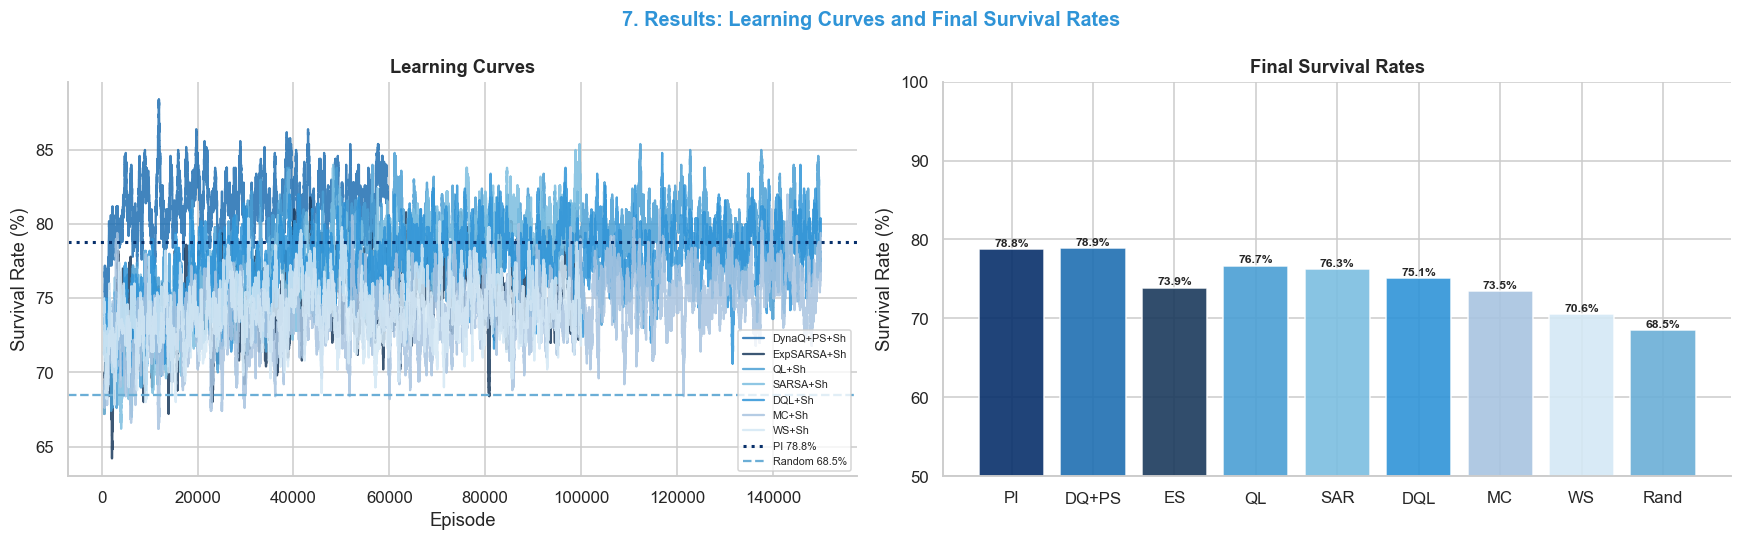

In [64]:
fig,axes=plt.subplots(1,2,figsize=(16,5))
fig.suptitle('7. Results: Learning Curves and Final Survival Rates',fontsize=13,fontweight='bold',color=H_COL)
for ret,col,lab in [(dq_returns,C_DQ,'DynaQ+PS+Sh'),(es_returns,C_ES,'ExpSARSA+Sh'),
                     (ql_returns,C_QL,'QL+Sh'),(sar_returns,C_SAR,'SARSA+Sh'),
                     (dql_returns,C_DQL,'DQL+Sh'),(mc_returns,C_MC,'MC+Sh'),(ws_returns,C_WS,'WS+Sh')]:
    sw=min(500,max(1,len(ret)//10)); s=smooth((np.array(ret)>0).astype(float)*100,sw)
    axes[0].plot(np.arange(sw,len(ret)+1),s,color=col,lw=1.5,alpha=0.85,label=lab)
axes[0].axhline(pi_survival,color=REF_PI,lw=2,ls=':',label=f'PI {pi_survival:.1f}%')
axes[0].axhline(rand_survival,color=REF_RAND,lw=1.5,ls='--',label=f'Random {rand_survival:.1f}%')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_title('Learning Curves',fontweight='bold'); axes[0].legend(fontsize=7)
axes[0].spines[['top','right']].set_visible(False)
all_a=[('PI',pi_survival,REF_PI),('DQ+PS',dq_survival,C_DQ),('ES',es_survival,C_ES),
       ('QL',ql_survival,C_QL),('SAR',sar_survival,C_SAR),('DQL',dql_survival,C_DQL),
       ('MC',mc_survival,C_MC),('WS',ws_survival,C_WS),('Rand',rand_survival,REF_RAND)]
bars=axes[1].bar([a[0] for a in all_a],[a[1] for a in all_a],color=[a[2] for a in all_a],edgecolor='white',alpha=0.9)
axes[1].set_ylabel('Survival Rate (%)'); axes[1].set_ylim(50,100)
axes[1].set_title('Final Survival Rates',fontweight='bold'); axes[1].spines[['top','right']].set_visible(False)
for bar,a in zip(bars,all_a):
    axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f'{a[1]:.1f}%',ha='center',fontsize=8,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_7_final.png',dpi=150,bbox_inches='tight'); plt.show()


# <font color='#2f94d7' size=6>**8. Comparative Analysis**</font> <a class="anchor" id="8"></a>

[Back to TOC](#toc)

**Algorithm 1: Policy Iteration** is the provably optimal solution for this MDP. With full
model access it solves the Bellman equations exactly, providing both the optimal policy and
V_PI(s) as a clinical acuity score (survival probability from each state).

**Algorithm 2: Dyna-Q with Prioritized Sweeping and Shaping** is the best model-free and
hybrid algorithm across all Optuna-optimised candidates. Three components address the
credit assignment challenge: (1) k planning steps multiply update efficiency per episode;
(2) prioritised sweeping focuses planning on high-uncertainty pairs; (3) reward shaping
converts the sparse terminal signal into dense per-step feedback proportional to progress
toward survival, enabling all model-free algorithms to converge significantly faster.

The candidate comparison confirms that planning (Dyna-Q+PS) consistently outperforms pure
model-free TD methods at equal real-episode counts, directly quantifying the value of
model access for credit assignment in sparse-reward clinical environments.


In [66]:
best_mf2=max([(dq_survival,'Dyna-Q+PS+Shaping'),(es_survival,'Expected SARSA(lam)+Shaping'),
               (ql_survival,'Q-Learning+Shaping'),(sar_survival,'SARSA(lam)+Shaping'),
               (dql_survival,'Double Q-Learning+Shaping'),(mc_survival,'MC+Shaping'),
               (ws_survival,'V_PI Warm-Start+Shaping')],key=lambda x:x[0])
print('='*70)
print(f'  {"CONFIG A: FINAL SUMMARY":^66}')
print('='*70)
print(f'  Configuration : sofa_bias={SOFA_BIAS}, lam={LAM}')
print(f'  Optuna        : {N_TRIALS} trials x {TRIAL_EPS:,} episodes per trial')
print('='*70)
print(f'  {"":40} {"Survival":>12} {"vs Random":>12}')
print('-'*70)
print(f'  {"Random Baseline":<40} {rand_survival:>9.1f}% {"---":>12}')
print(f'  {"Policy Iteration (Algorithm 1)":<40} {pi_survival:>9.1f}% {pi_survival-rand_survival:>+11.1f}pp')
print(f'  {best_mf2[1]+" (Algorithm 2)":<40} {best_mf2[0]:>9.1f}% {best_mf2[0]-rand_survival:>+11.1f}pp')
print('='*70)


                       CONFIG A: FINAL SUMMARY                      
  Configuration : sofa_bias=5.0, lam=0.02
  Optuna        : 30 trials x 40,000 episodes per trial
                                               Survival    vs Random
----------------------------------------------------------------------
  Random Baseline                               68.5%          ---
  Policy Iteration (Algorithm 1)                78.8%       +10.3pp
  Dyna-Q+PS+Shaping (Algorithm 2)               78.9%       +10.4pp
